## Package Installation


In [1]:
# Optional installation cell
# Run only when packages are missing.
#
# %pip install -q pandas numpy scipy scikit-learn imbalanced-learn
# %pip install -q xgboost lightgbm catboost shap lime joblib pyarrow tabulate pillow


## Imports, Reproducibility, and Execution Configuration


In [2]:
import os

# Deterministic thread defaults. Override explicitly through environment variables when needed.
for _thread_variable in ["OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "VECLIB_MAXIMUM_THREADS", "NUMEXPR_NUM_THREADS"]:
    os.environ.setdefault(_thread_variable, "1")
os.environ.setdefault("PYTHONHASHSEED", "42")

import sys
import json
import time
import random
import hashlib
import shutil
import warnings
import platform
import importlib.metadata as importlib_metadata
from pathlib import Path
from datetime import datetime
from typing import Dict, List, Tuple, Any, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.special import expit, logit
from scipy.stats import spearmanr, wilcoxon
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    matthews_corrcoef,
    balanced_accuracy_score,
    accuracy_score,
    precision_score,
    brier_score_loss,
    log_loss,
)
from sklearn.model_selection import (
    StratifiedKFold,
    RandomizedSearchCV,
    cross_val_predict,
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from imblearn.over_sampling import RandomOverSampler, SMOTENC
from imblearn.pipeline import Pipeline
import joblib

warnings.filterwarnings("ignore")

PRIMARY_SEED = 42
STABILITY_SEEDS = [42, 7, 2026]
random.seed(PRIMARY_SEED)
np.random.seed(PRIMARY_SEED)

RUN_PROFILE = os.getenv("CKD_RUN_PROFILE", "paper").strip().lower()
PROFILES = {
    "smoke": {
        "outer_folds": 2,
        "inner_folds": 2,
        "simple_tune_iterations": 1,
        "boosting_tune_iterations": 1,
        "robustness_tune_iterations": 1,
        "bootstrap_iterations": 100,
        "permutation_repeats": 1,
        "run_calibration": False,
        "run_robustness": False,
        "run_seed_stability": False,
        "run_shap": False,
        "run_lime": False,
        "run_interactions": False,
        "run_learning_curves": False,
        "models": ["logistic_regression", "random_forest"],
    },
    "standard": {
        "outer_folds": 5,
        "inner_folds": 3,
        "simple_tune_iterations": 5,
        "boosting_tune_iterations": 10,
        "robustness_tune_iterations": 3,
        "bootstrap_iterations": 500,
        "permutation_repeats": 5,
        "run_calibration": True,
        "run_robustness": False,
        "run_seed_stability": False,
        "run_shap": True,
        "run_lime": True,
        "run_interactions": False,
        "run_learning_curves": True,
        "models": "all",
    },
    "paper": {
        "outer_folds": 5,
        "inner_folds": 3,
        "simple_tune_iterations": 12,
        "boosting_tune_iterations": 30,
        "robustness_tune_iterations": 5,
        "bootstrap_iterations": 2000,
        "permutation_repeats": 10,
        "run_calibration": True,
        "run_robustness": True,
        "run_seed_stability": True,
        "run_shap": True,
        "run_lime": True,
        "run_interactions": True,
        "run_learning_curves": True,
        "models": "all",
    },
}
if RUN_PROFILE not in PROFILES:
    raise ValueError("Use smoke, standard, or paper.")

CFG = PROFILES[RUN_PROFILE]
OUTER_FOLDS = int(CFG["outer_folds"])
INNER_FOLDS = int(CFG["inner_folds"])
SIMPLE_TUNE_ITERATIONS = int(CFG["simple_tune_iterations"])
BOOSTING_TUNE_ITERATIONS = int(CFG["boosting_tune_iterations"])
ROBUSTNESS_TUNE_ITERATIONS = int(CFG["robustness_tune_iterations"])
BOOTSTRAP_ITERATIONS = int(CFG["bootstrap_iterations"])
PERMUTATION_REPEATS = int(CFG["permutation_repeats"])


def env_flag(name: str, default: bool) -> bool:
    value = os.getenv(name)
    if value is None:
        return bool(default)
    return value.strip().lower() in {"1", "true", "yes", "on"}


RUN_CALIBRATION = env_flag("CKD_RUN_CALIBRATION", CFG["run_calibration"])
RUN_ROBUSTNESS = env_flag("CKD_RUN_ROBUSTNESS", CFG["run_robustness"])
RUN_SEED_STABILITY = env_flag("CKD_RUN_SEED_STABILITY", CFG["run_seed_stability"])
RUN_SHAP = env_flag("CKD_RUN_SHAP", CFG["run_shap"])
RUN_LIME = env_flag("CKD_RUN_LIME", CFG["run_lime"])
RUN_INTERACTIONS = env_flag("CKD_RUN_INTERACTIONS", CFG["run_interactions"])
RUN_LEARNING_CURVES = env_flag("CKD_RUN_LEARNING_CURVES", CFG["run_learning_curves"])
N_JOBS = int(os.getenv("CKD_N_JOBS", "1"))

OUTPUT_ROOT = Path(
    os.getenv(
        "CKD_OUTPUT_DIR",
        "/kaggle/working/pipeline2_next_observation_outputs",
    )
)
TABLES = OUTPUT_ROOT / "tables"
FIGURES = OUTPUT_ROOT / "figures"
MODELS = OUTPUT_ROOT / "models"
REPORTS = OUTPUT_ROOT / "reports"
SUPPLEMENTARY = OUTPUT_ROOT / "supplementary"
ARTIFACTS = OUTPUT_ROOT / "artifacts"
RAW_DATA = OUTPUT_ROOT / "raw_data"
PREPROCESSED_DATA = OUTPUT_ROOT / "preprocessed_data"
for folder in [OUTPUT_ROOT, TABLES, FIGURES, MODELS, REPORTS, SUPPLEMENTARY, ARTIFACTS, RAW_DATA, PREPROCESSED_DATA]:
    folder.mkdir(parents=True, exist_ok=True)



## Dataset Loading, Audit, and CKD Onset Construction


In [3]:
def locate_dataset() -> Path:
    requested = os.getenv("CKD_DATASET_PATH", "").strip()
    candidates = []
    if requested:
        candidates.append(Path(requested))

    candidates.extend([
        Path("/kaggle/input/datasets/miftahuladib/datasets-ckd/DiabeticCKD_dataset (1).csv"),
        Path("/mnt/data/DiabeticCKD_dataset (1) (6).csv"),
        Path("/mnt/data/DiabeticCKD_dataset (1).csv"),
        Path("DiabeticCKD_dataset (1).csv"),
        Path("DiabeticCKD_dataset.csv"),
    ])

    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()

    for root in [Path("/kaggle/input"), Path("/mnt/data"), Path.cwd()]:
        if root.exists():
            matches = list(root.rglob("*Diabetic*CKD*.csv"))
            if matches:
                return sorted(matches, key=lambda path: len(str(path)))[0].resolve()

    raise FileNotFoundError("Dataset 2 was not found. Set CKD_DATASET_PATH.")


def file_sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


DATASET_PATH = locate_dataset()
raw = pd.read_csv(DATASET_PATH)

# Preserve the exact source file and also provide a consistently named CSV copy.
RAW_SOURCE_COPY = RAW_DATA / f"Dataset2_raw_original{DATASET_PATH.suffix.lower()}"
shutil.copy2(DATASET_PATH, RAW_SOURCE_COPY)
RAW_NORMALIZED_COPY = RAW_DATA / "Dataset2_raw.csv"
raw.to_csv(RAW_NORMALIZED_COPY, index=False)

COLUMN_MAP = {
    "Patient ID": "patient_id",
    "Gender (M-male, F-female)": "gender",
    "Job (1-normal, 2-intermediate, 3-heavy)": "job",
    "Family Background of Diabetes (1-yes, 0-no)": "family_diabetes",
    "Height (cm)": "height_cm",
    "Diabetic Year": "diabetic_year",
    "Age": "age",
    "Average Age": "average_age",
    "Weight (kg)": "weight_kg",
    "Average Weight (kg)": "average_weight_kg",
    "BMI": "stored_bmi",
    "Follow suggested Diet (1-yes, 0-no)": "follow_diet",
    "Take Medicine for Diabetes (1-yes, 0-no)": "take_medicine",
    "Take Insulin (1-yes, 0-no)": "insulin",
    "Hypertension (1-yes, 0-no)": "hypertension",
    "Heart Disease (1-yes, 0-no)": "heart_disease",
    "Sleep (1-sufficient, 0-insufficient)": "sleep_sufficient",
    "Water Consumption (1-sufficient, 0-insufficient)": "water_sufficient",
    "Smoke (1-yes, 0-no)": "smoke",
    "Zarda, Betel Leaf (1-yes, 0-no)": "zarda_betel",
    "Walk Regularly (1-yes, 0-no)": "walk_regularly",
    "Urination Properly (1-yes, 0-no)": "urination_proper",
    "Urinary Infection (1-yes, 0-no)": "urinary_infection",
    "Pain killer (1-yes, 0-no)": "pain_killer",
    "Calorie Intake (per day)": "calorie_intake",
    "CKD (1-yes, 0-no)": "ckd",
}

missing = sorted(set(COLUMN_MAP) - set(raw.columns))
if missing:
    raise ValueError(f"Missing required columns: {missing}")

data = raw.rename(columns=COLUMN_MAP).copy()
data["gender"] = data["gender"].map({"F": 0, "M": 1})
if data["gender"].isna().any():
    raise ValueError("Unexpected gender values were found.")

numeric_columns = [column for column in COLUMN_MAP.values() if column != "gender"]
for column in numeric_columns:
    data[column] = pd.to_numeric(data[column], errors="raise")

data = data.sort_values(
    ["patient_id", "diabetic_year"],
    kind="mergesort",
).reset_index(drop=True)
data["source_row_id"] = np.arange(len(data), dtype=int)
data["visit_index"] = data.groupby("patient_id").cumcount() + 1
data["bmi_current"] = data["weight_kg"] / np.square(data["height_cm"] / 100.0)
data["previous_ckd"] = data.groupby("patient_id")["ckd"].shift(1)
data["ckd_reversal"] = ((data["previous_ckd"] == 1) & (data["ckd"] == 0)).astype(int)

patient_audit = (
    data.groupby("patient_id")
    .agg(
        records=("source_row_id", "size"),
        positive_records=("ckd", "sum"),
        ever_ckd=("ckd", "max"),
        first_status=("ckd", "first"),
        final_status=("ckd", "last"),
        ckd_reversals=("ckd_reversal", "sum"),
    )
    .reset_index()
)

first_onset = (
    data.loc[data["ckd"] == 1]
    .groupby("patient_id")["visit_index"]
    .min()
    .rename("first_onset_visit")
)
patient_audit = patient_audit.merge(first_onset, on="patient_id", how="left")


def onset_stratum(value: float) -> str:
    if pd.isna(value):
        return "never"
    if value <= 4:
        return "early"
    if value <= 6:
        return "middle_early"
    if value <= 8:
        return "middle_late"
    return "late"


patient_audit["onset_stratum"] = patient_audit["first_onset_visit"].apply(onset_stratum)

duplicate_patient_year = int(data.duplicated(["patient_id", "diabetic_year"]).sum())
audit_summary = pd.DataFrame({
    "measure": [
        "records",
        "patients",
        "minimum_records_per_patient",
        "maximum_records_per_patient",
        "positive_records",
        "record_prevalence",
        "patients_ever_ckd",
        "patients_never_ckd",
        "patients_with_ckd_reversal",
        "ckd_reversal_rows",
        "missing_cells",
        "duplicate_rows",
        "duplicate_patient_year_rows",
    ],
    "value": [
        len(data),
        data["patient_id"].nunique(),
        patient_audit["records"].min(),
        patient_audit["records"].max(),
        int(data["ckd"].sum()),
        float(data["ckd"].mean()),
        int(patient_audit["ever_ckd"].sum()),
        int((patient_audit["ever_ckd"] == 0).sum()),
        int((patient_audit["ckd_reversals"] > 0).sum()),
        int(data["ckd_reversal"].sum()),
        int(data.isna().sum().sum()),
        int(data.duplicated().sum()),
        duplicate_patient_year,
    ],
})

patient_audit.to_csv(TABLES / "01_patient_audit.csv", index=False)
audit_summary.to_csv(TABLES / "02_dataset_audit.csv", index=False)

environment = {
    "created_at": datetime.now().isoformat(),
    "python": sys.version,
    "platform": platform.platform(),
    "profile": RUN_PROFILE,
    "primary_seed": PRIMARY_SEED,
    "stability_seeds": STABILITY_SEEDS,
    "dataset_path": str(DATASET_PATH),
    "dataset_sha256": file_sha256(DATASET_PATH),
}
with (OUTPUT_ROOT / "environment.json").open("w", encoding="utf-8") as stream:
    json.dump(environment, stream, indent=2)



## Temporal Feature Engineering and Preprocessing


In [4]:
BINARY_HISTORY = [
    "follow_diet",
    "take_medicine",
    "insulin",
    "hypertension",
    "heart_disease",
    "sleep_sufficient",
    "water_sufficient",
    "smoke",
    "zarda_betel",
    "walk_regularly",
    "urination_proper",
    "urinary_infection",
    "pain_killer",
]

CURRENT_BINARY_ORDINAL = [
    "gender",
    "job",
    "family_diabetes",
    *BINARY_HISTORY,
]


def prior_slope(values: np.ndarray) -> np.ndarray:
    values = np.asarray(values, dtype=float)
    slopes = np.full(len(values), np.nan)
    for position in range(len(values)):
        history = values[:position]
        if len(history) >= 2 and np.isfinite(history).all():
            slopes[position] = np.polyfit(
                np.arange(len(history), dtype=float),
                history,
                1,
            )[0]
    return slopes


def feature_family(feature: str) -> str:
    suffixes = [
        "_past_slope",
        "_past_mean",
        "_past_min",
        "_past_max",
        "_delta1",
        "_lag1",
    ]
    family = feature
    for suffix in suffixes:
        if family.endswith(suffix):
            family = family[: -len(suffix)]
            break
    mapping = {
        "bmi_current": "bmi",
        "stored_bmi": "bmi",
        "diabetic_year": "diabetic_year",
        "prior_visit_count": "prior_visit_count",
    }
    return mapping.get(family, family)


def build_pipeline_two(
    source: pd.DataFrame,
    bmi_column: str = "bmi_current",
) -> Tuple[pd.DataFrame, List[str], List[str], pd.DataFrame]:
    frame = source.copy().sort_values(
        ["patient_id", "diabetic_year"],
        kind="mergesort",
    ).reset_index(drop=True)

    grouped = frame.groupby("patient_id", sort=False, group_keys=False)
    frame["future_ckd_1"] = grouped["ckd"].shift(-1)
    frame["complete_horizon"] = frame["future_ckd_1"].notna()
    frame["target"] = frame["future_ckd_1"]
    frame["prior_visit_count"] = grouped.cumcount()
    frame["prior_ckd_max"] = grouped["ckd"].transform(
        lambda values: values.shift(1).cummax()
    ).fillna(0)

    continuous_history = ["weight_kg", bmi_column, "calorie_intake"]
    current_features = [
        "gender",
        "job",
        "family_diabetes",
        "height_cm",
        "diabetic_year",
        "age",
        "weight_kg",
        bmi_column,
        *BINARY_HISTORY,
        "calorie_intake",
        "prior_visit_count",
    ]

    generated = []
    for column in continuous_history + BINARY_HISTORY:
        lag_name = f"{column}_lag1"
        delta_name = f"{column}_delta1"
        mean_name = f"{column}_past_mean"

        frame[lag_name] = grouped[column].shift(1)
        frame[delta_name] = frame[column] - frame[lag_name]

        shifted = grouped[column].shift(1)
        frame[mean_name] = (
            shifted.groupby(frame["patient_id"])
            .expanding()
            .mean()
            .reset_index(level=0, drop=True)
        )
        generated.extend([lag_name, delta_name, mean_name])

    for column in continuous_history:
        shifted = grouped[column].shift(1)
        minimum_name = f"{column}_past_min"
        maximum_name = f"{column}_past_max"
        slope_name = f"{column}_past_slope"

        frame[minimum_name] = (
            shifted.groupby(frame["patient_id"])
            .expanding()
            .min()
            .reset_index(level=0, drop=True)
        )
        frame[maximum_name] = (
            shifted.groupby(frame["patient_id"])
            .expanding()
            .max()
            .reset_index(level=0, drop=True)
        )

        slopes = np.full(len(frame), np.nan)
        for _, patient_rows in frame.groupby("patient_id", sort=False):
            indices = patient_rows.index.to_numpy()
            slopes[indices] = prior_slope(patient_rows[column].to_numpy(dtype=float))
        frame[slope_name] = slopes
        generated.extend([minimum_name, maximum_name, slope_name])

    modeling = frame.loc[
        (frame["ckd"] == 0)
        & (frame["prior_ckd_max"] == 0)
        & frame["complete_horizon"]
    ].copy()
    modeling["target"] = modeling["target"].astype(int)

    features = list(dict.fromkeys(current_features + generated))
    forbidden = {
        "patient_id",
        "source_row_id",
        "ckd",
        "target",
        "future_ckd_1",
        "prior_ckd_max",
        "average_age",
        "average_weight_kg",
    }
    if bmi_column == "bmi_current":
        forbidden.add("stored_bmi")
    overlap = sorted(set(features) & forbidden)
    if overlap:
        raise AssertionError(f"Forbidden features: {overlap}")

    categorical_features = [
        feature for feature in features
        if feature in CURRENT_BINARY_ORDINAL
        or any(feature == f"{column}_lag1" for column in BINARY_HISTORY)
    ]
    continuous_features = [feature for feature in features if feature not in categorical_features]
    metadata = pd.DataFrame({
        "feature": features,
        "feature_family": [feature_family(feature) for feature in features],
        "feature_role": [
            "categorical_or_binary" if feature in categorical_features else "continuous"
            for feature in features
        ],
        "source": [
            "current" if feature in current_features else "strict_past_history"
            for feature in features
        ],
    })

    return modeling.reset_index(drop=True), features, current_features, metadata


model_data, FEATURES, CURRENT_FEATURES, FEATURE_METADATA = build_pipeline_two(
    data,
    bmi_column="bmi_current",
)
model_data_stored_bmi, STORED_BMI_FEATURES, STORED_BMI_CURRENT_FEATURES, STORED_BMI_METADATA = build_pipeline_two(
    data,
    bmi_column="stored_bmi",
)

if not np.array_equal(
    model_data["source_row_id"].to_numpy(),
    model_data_stored_bmi["source_row_id"].to_numpy(),
):
    raise AssertionError("Corrected BMI and stored BMI cohorts are not aligned.")

checks = pd.DataFrame({
    "check": [
        "current_ckd_is_zero",
        "no_prior_ckd",
        "complete_future_horizon",
        "patient_id_excluded",
        "stored_patient_summaries_excluded",
        "stored_bmi_excluded_from_main",
        "future_labels_excluded",
        "first_onset_positive_count_matches_patients_ever_ckd",
    ],
    "passed": [
        bool((model_data["ckd"] == 0).all()),
        bool((model_data["prior_ckd_max"] == 0).all()),
        bool(model_data["complete_horizon"].all()),
        "patient_id" not in FEATURES,
        not bool({"average_age", "average_weight_kg"} & set(FEATURES)),
        "stored_bmi" not in FEATURES,
        not bool({"future_ckd_1", "target", "ckd"} & set(FEATURES)),
        int(model_data["target"].sum()) == int(patient_audit["ever_ckd"].sum()),
    ],
})
if not checks["passed"].all():
    raise AssertionError("A temporal or predictor leakage check failed.")

target_summary = pd.DataFrame({
    "measure": [
        "eligible_examples",
        "positive_examples",
        "negative_examples",
        "positive_prevalence",
        "patients",
        "main_features",
        "current_features",
        "history_features",
    ],
    "value": [
        len(model_data),
        int(model_data["target"].sum()),
        int((model_data["target"] == 0).sum()),
        float(model_data["target"].mean()),
        int(model_data["patient_id"].nunique()),
        len(FEATURES),
        len(CURRENT_FEATURES),
        len(FEATURES) - len(CURRENT_FEATURES),
    ],
})

removed_predictors = pd.DataFrame({
    "predictor": [
        "patient_id",
        "average_age",
        "average_weight_kg",
        "stored_bmi",
        "current_ckd",
        "future_ckd_label",
    ],
    "main_analysis_action": [
        "grouping_only",
        "removed_patient_summary",
        "removed_patient_summary",
        "replaced_by_recalculated_current_bmi",
        "eligibility_only",
        "target_only",
    ],
    "reason": [
        "prevents patient leakage",
        "may summarize later observations",
        "may summarize later observations",
        "current BMI is recomputed from current height and weight",
        "not used as a predictor",
        "future information cannot enter predictors",
    ],
})

continuous_table = (
    model_data[[
        "age", "diabetic_year", "height_cm", "weight_kg", "bmi_current", "calorie_intake"
    ]]
    .describe(percentiles=[0.25, 0.5, 0.75])
    .T
    .reset_index()
    .rename(columns={"index": "variable"})
)

binary_table = pd.DataFrame({
    "variable": CURRENT_BINARY_ORDINAL,
    "count": [int(model_data[column].notna().sum()) for column in CURRENT_BINARY_ORDINAL],
    "value_one_count": [int(model_data[column].sum()) for column in CURRENT_BINARY_ORDINAL],
    "value_one_proportion": [float(model_data[column].mean()) for column in CURRENT_BINARY_ORDINAL],
})

model_data.to_csv(TABLES / "03_modeling_dataset.csv", index=False)
PREPROCESSED_EXPORT_COLUMNS = list(dict.fromkeys([
    "patient_id", "source_row_id", "visit_index", "diabetic_year", "target", *FEATURES
]))
PREPROCESSED_DATASET = model_data[PREPROCESSED_EXPORT_COLUMNS].copy()
PREPROCESSED_DATASET.to_csv(
    PREPROCESSED_DATA / "Dataset2_preprocessed.csv",
    index=False,
)
FEATURE_METADATA.to_csv(TABLES / "04_feature_list_and_roles.csv", index=False)
checks.to_csv(TABLES / "05_temporal_checks.csv", index=False)
target_summary.to_csv(TABLES / "06_target_summary.csv", index=False)
removed_predictors.to_csv(TABLES / "paper_table_1c_removed_and_derived_predictors.csv", index=False)
continuous_table.to_csv(TABLES / "paper_table_1a_dataset2_continuous_characteristics.csv", index=False)
binary_table.to_csv(TABLES / "paper_table_1b_dataset2_binary_characteristics.csv", index=False)



## Patient Grouped Cross Validation Splits


In [5]:
patient_strata = patient_audit[["patient_id", "onset_stratum"]].copy()


def make_patient_splits(
    frame: pd.DataFrame,
    n_splits: int,
    seed: int,
) -> List[Tuple[np.ndarray, np.ndarray]]:
    patients = (
        frame[["patient_id"]]
        .drop_duplicates()
        .merge(patient_strata, on="patient_id", how="left")
        .sort_values("patient_id")
        .reset_index(drop=True)
    )

    counts = patients["onset_stratum"].value_counts()
    if counts.min() < n_splits:
        patients["split_stratum"] = np.where(
            patients["onset_stratum"] == "never",
            "never",
            "ever",
        )
    else:
        patients["split_stratum"] = patients["onset_stratum"]

    splitter = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=seed,
    )

    output = []
    for train_positions, test_positions in splitter.split(
        patients["patient_id"],
        patients["split_stratum"],
    ):
        train_patients = set(patients.iloc[train_positions]["patient_id"])
        test_patients = set(patients.iloc[test_positions]["patient_id"])
        if train_patients & test_patients:
            raise AssertionError("Patient overlap was detected.")

        train_indices = np.flatnonzero(frame["patient_id"].isin(train_patients).to_numpy())
        test_indices = np.flatnonzero(frame["patient_id"].isin(test_patients).to_numpy())
        output.append((train_indices, test_indices))

    return output


def make_record_splits(
    frame: pd.DataFrame,
    n_splits: int,
    seed: int,
) -> List[Tuple[np.ndarray, np.ndarray]]:
    splitter = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=seed,
    )
    return [
        (train_indices, test_indices)
        for train_indices, test_indices in splitter.split(frame, frame["target"])
    ]


OUTER_SPLITS = make_patient_splits(model_data, OUTER_FOLDS, PRIMARY_SEED)

fold_rows = []
for fold_number, (train_indices, test_indices) in enumerate(OUTER_SPLITS, start=1):
    train_fold = model_data.iloc[train_indices]
    test_fold = model_data.iloc[test_indices]
    if set(train_fold["patient_id"]) & set(test_fold["patient_id"]):
        raise AssertionError("Patient overlap was detected in the outer split.")
    if test_fold["target"].nunique() < 2:
        raise AssertionError("An outer fold contains only one target class.")
    fold_rows.append({
        "outer_fold": fold_number,
        "examples": len(test_fold),
        "patients": test_fold["patient_id"].nunique(),
        "positives": int(test_fold["target"].sum()),
        "prevalence": float(test_fold["target"].mean()),
    })

FOLD_BALANCE = pd.DataFrame(fold_rows)
FOLD_BALANCE.to_csv(TABLES / "07_outer_fold_balance.csv", index=False)


## Model Definitions and Hyperparameter Search Spaces


In [6]:
OPTIONAL = {}
try:
    from xgboost import XGBClassifier
    OPTIONAL["xgboost"] = XGBClassifier
except Exception as error:
    pass

try:
    from lightgbm import LGBMClassifier
    OPTIONAL["lightgbm"] = LGBMClassifier
except Exception as error:
    pass

try:
    from catboost import CatBoostClassifier
    OPTIONAL["catboost"] = CatBoostClassifier
except Exception as error:
    pass


MAIN_MODELS = [
    "logistic_regression",
    "decision_tree",
    "random_forest",
    "xgboost",
    "lightgbm",
    "catboost",
    "svm_rbf",
    "mlp",
]
EXPLORATORY_MODELS = ["extra_trees", "hist_gradient_boosting"]
TREE_MODELS = {
    "decision_tree",
    "random_forest",
    "extra_trees",
    "xgboost",
    "lightgbm",
    "catboost",
    "hist_gradient_boosting",
}
BOOSTING_MODELS = {
    "xgboost",
    "lightgbm",
    "catboost",
    "hist_gradient_boosting",
}
SIMPLICITY_RANK = {
    "logistic_regression": 1,
    "decision_tree": 2,
    "random_forest": 3,
    "extra_trees": 4,
    "hist_gradient_boosting": 5,
    "xgboost": 6,
    "lightgbm": 7,
    "catboost": 8,
    "svm_rbf": 9,
    "mlp": 10,
}

available_models = []
for model_name in MAIN_MODELS + EXPLORATORY_MODELS:
    if model_name in {"xgboost", "lightgbm", "catboost"} and model_name not in OPTIONAL:
        continue
    available_models.append(model_name)

if CFG.get("models") == "all":
    selected_available_models = available_models
else:
    selected_available_models = [
        model for model in CFG.get("models", []) if model in available_models
    ]
MODEL_NAMES = ["dummy", "time_only_logistic"] + selected_available_models


def class_ratio(y: np.ndarray) -> float:
    positives = int(np.sum(y))
    negatives = int(len(y) - positives)
    return negatives / positives if positives else 1.0


def feature_roles(features: List[str]) -> Tuple[List[str], List[str]]:
    metadata = FEATURE_METADATA.set_index("feature")
    categorical = [
        feature for feature in features
        if feature in metadata.index and metadata.loc[feature, "feature_role"] == "categorical_or_binary"
    ]
    continuous = [feature for feature in features if feature not in categorical]
    return continuous, categorical


def build_scaled_preprocessor(features: List[str]) -> ColumnTransformer:
    continuous, categorical = feature_roles(features)
    transformers = []
    if continuous:
        transformers.append((
            "continuous",
            SklearnPipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            continuous,
        ))
    if categorical:
        transformers.append((
            "categorical",
            SklearnPipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
            ]),
            categorical,
        ))
    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=False,
    )


def build_estimator(
    model_name: str,
    y_train: np.ndarray,
    random_seed: int,
    features_override: Optional[List[str]] = None,
    imbalance_strategy: str = "class_weight",
) -> Tuple[Pipeline, Dict[str, List[Any]], List[str]]:
    if imbalance_strategy not in {"class_weight", "none", "smotenc"}:
        raise ValueError("Use class_weight, none, or smotenc.")

    ratio = class_ratio(y_train)
    features = list(features_override or FEATURES)
    use_weight = imbalance_strategy == "class_weight"
    needs_scaling = model_name in {"time_only_logistic", "logistic_regression", "svm_rbf", "mlp"}

    if model_name == "dummy":
        model = DummyClassifier(strategy="stratified", random_state=random_seed)
        space = {}

    elif model_name == "time_only_logistic":
        features = ["age", "diabetic_year"]
        model = LogisticRegression(
            class_weight="balanced" if use_weight else None,
            max_iter=3000,
            random_state=random_seed,
        )
        space = {}

    elif model_name == "logistic_regression":
        model = LogisticRegression(
            class_weight="balanced" if use_weight else None,
            solver="lbfgs",
            max_iter=3000,
            random_state=random_seed,
        )
        space = {"model__C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10]}

    elif model_name == "decision_tree":
        model = DecisionTreeClassifier(
            class_weight="balanced" if use_weight else None,
            random_state=random_seed,
        )
        space = {
            "model__criterion": ["gini", "entropy", "log_loss"],
            "model__max_depth": [3, 5, 7, 10, None],
            "model__min_samples_leaf": [2, 5, 10, 20],
            "model__min_samples_split": [2, 5, 10],
        }

    elif model_name == "random_forest":
        model = RandomForestClassifier(
            class_weight="balanced_subsample" if use_weight else None,
            random_state=random_seed,
            n_jobs=1,
        )
        space = {
            "model__n_estimators": [300, 500, 700],
            "model__max_depth": [None, 6, 10, 14],
            "model__min_samples_leaf": [1, 2, 5, 10],
            "model__max_features": ["sqrt", "log2", 0.5],
        }

    elif model_name == "extra_trees":
        model = ExtraTreesClassifier(
            class_weight="balanced" if use_weight else None,
            random_state=random_seed,
            n_jobs=1,
        )
        space = {
            "model__n_estimators": [300, 500, 700],
            "model__max_depth": [None, 6, 10, 14],
            "model__min_samples_leaf": [1, 2, 5, 10],
            "model__max_features": ["sqrt", "log2", 0.5],
        }

    elif model_name == "xgboost":
        model = OPTIONAL["xgboost"](
            objective="binary:logistic",
            eval_metric="logloss",
            scale_pos_weight=ratio if use_weight else 1.0,
            tree_method="hist",
            random_state=random_seed,
            n_jobs=1,
        )
        space = {
            "model__n_estimators": [250, 400, 600],
            "model__max_depth": [3, 4, 5, 6],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__subsample": [0.7, 0.85, 1.0],
            "model__colsample_bytree": [0.7, 0.85, 1.0],
            "model__min_child_weight": [1, 3, 5],
            "model__reg_lambda": [1, 3, 10],
        }

    elif model_name == "lightgbm":
        model = OPTIONAL["lightgbm"](
            objective="binary",
            scale_pos_weight=ratio if use_weight else 1.0,
            random_state=random_seed,
            n_jobs=1,
            verbosity=-1,
        )
        space = {
            "model__n_estimators": [250, 400, 600],
            "model__num_leaves": [15, 31, 63],
            "model__max_depth": [-1, 5, 8, 12],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__subsample": [0.7, 0.85, 1.0],
            "model__colsample_bytree": [0.7, 0.85, 1.0],
            "model__reg_lambda": [0, 1, 5],
        }

    elif model_name == "catboost":
        catboost_options = {
            "loss_function": "Logloss",
            "eval_metric": "PRAUC",
            "random_seed": random_seed,
            "verbose": False,
            "thread_count": 1,
            "allow_writing_files": False,
        }
        if use_weight:
            catboost_options["auto_class_weights"] = "Balanced"
        model = OPTIONAL["catboost"](**catboost_options)
        space = {
            "model__iterations": [250, 400, 600],
            "model__depth": [4, 6, 8],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__l2_leaf_reg": [1, 3, 5, 10],
            "model__random_strength": [0, 0.5, 1],
        }

    elif model_name == "hist_gradient_boosting":
        model = HistGradientBoostingClassifier(
            class_weight="balanced" if use_weight else None,
            random_state=random_seed,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=20,
        )
        space = {
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__max_iter": [200, 350, 500],
            "model__max_leaf_nodes": [15, 31, 63],
            "model__min_samples_leaf": [10, 20, 30],
            "model__l2_regularization": [0, 0.1, 1, 5],
        }

    elif model_name == "svm_rbf":
        model = SVC(
            kernel="rbf",
            class_weight="balanced" if use_weight else None,
            probability=True,
            random_state=random_seed,
        )
        space = {
            "model__C": [0.1, 0.3, 1, 3, 10, 30],
            "model__gamma": ["scale", "auto", 0.001, 0.01, 0.1],
        }

    elif model_name == "mlp":
        model = MLPClassifier(
            activation="relu",
            solver="adam",
            max_iter=800,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=30,
            random_state=random_seed,
        )
        space = {
            "model__hidden_layer_sizes": [(32,), (64,), (64, 32)],
            "model__alpha": [0.0001, 0.001, 0.01, 0.1],
            "model__learning_rate_init": [0.0003, 0.001, 0.003],
        }

    else:
        raise KeyError(model_name)

    if imbalance_strategy == "smotenc" and model_name not in {"dummy", "time_only_logistic"}:
        _, categorical = feature_roles(features)
        categorical_indices = [features.index(feature) for feature in categorical]
        steps = [
            ("imputer", SimpleImputer(strategy="median")),
            (
                "sampler",
                SMOTENC(
                    categorical_features=categorical_indices,
                    k_neighbors=1,
                    random_state=random_seed,
                ),
            ),
            ("scaler", StandardScaler() if needs_scaling else "passthrough"),
            ("model", model),
        ]
    else:
        preprocessor = build_scaled_preprocessor(features) if needs_scaling else SimpleImputer(strategy="median")
        sampler = "passthrough"
        if model_name == "mlp" and imbalance_strategy == "class_weight":
            sampler = RandomOverSampler(random_state=random_seed)
        steps = [
            ("preprocess", preprocessor),
            ("sampler", sampler),
            ("model", model),
        ]

    estimator = Pipeline(steps)
    return estimator, space, features


def tuning_iterations(model_name: str, override: Optional[int] = None) -> int:
    if override is not None:
        return int(override)
    return BOOSTING_TUNE_ITERATIONS if model_name in BOOSTING_MODELS else SIMPLE_TUNE_ITERATIONS




## Prediction, Thresholding, and Nested Evaluation


In [7]:
def predict_probability(estimator: Pipeline, X: pd.DataFrame) -> np.ndarray:
    if hasattr(estimator, "predict_proba"):
        probability = estimator.predict_proba(X)[:, 1]
    else:
        probability = expit(estimator.decision_function(X))
    return np.clip(np.asarray(probability, dtype=float), 1e-8, 1 - 1e-8)


def best_mcc_threshold(y_true: np.ndarray, probability: np.ndarray) -> float:
    candidates = np.unique(np.concatenate([np.linspace(0.01, 0.99, 199), probability]))
    best_threshold = 0.5
    best_score = -np.inf
    for threshold in candidates:
        prediction = (probability >= threshold).astype(int)
        score = matthews_corrcoef(y_true, prediction)
        if score > best_score:
            best_score = score
            best_threshold = float(threshold)
    return best_threshold


def expected_calibration_error(
    y_true: np.ndarray,
    probability: np.ndarray,
    bins: int = 10,
) -> float:
    edges = np.linspace(0, 1, bins + 1)
    result = 0.0
    for lower, upper in zip(edges[:-1], edges[1:]):
        if upper == 1:
            mask = (probability >= lower) & (probability <= upper)
        else:
            mask = (probability >= lower) & (probability < upper)
        if mask.any():
            result += mask.mean() * abs(y_true[mask].mean() - probability[mask].mean())
    return float(result)


def calculate_metrics(
    y_true: np.ndarray,
    probability: np.ndarray,
    threshold: float,
) -> Dict[str, float]:
    prediction = (probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, prediction, labels=[0, 1]).ravel()
    return {
        "pr_auc": average_precision_score(y_true, probability),
        "roc_auc": roc_auc_score(y_true, probability),
        "mcc": matthews_corrcoef(y_true, prediction),
        "f1": f1_score(y_true, prediction, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, prediction),
        "accuracy": accuracy_score(y_true, prediction),
        "precision": precision_score(y_true, prediction, zero_division=0),
        "sensitivity": tp / (tp + fn) if tp + fn else 0.0,
        "specificity": tn / (tn + fp) if tn + fp else 0.0,
        "brier": brier_score_loss(y_true, probability),
        "log_loss": log_loss(y_true, probability, labels=[0, 1]),
        "ece10": expected_calibration_error(y_true, probability),
        "threshold": threshold,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def evaluate_model_set(
    frame: pd.DataFrame,
    outer_splits: List[Tuple[np.ndarray, np.ndarray]],
    model_names: List[str],
    run_seed: int,
    output_tag: str,
    features_override: Optional[List[str]] = None,
    imbalance_strategy: str = "class_weight",
    tune_override: Optional[int] = None,
    inner_split_mode: str = "grouped",
    save_fitted_models: bool = False,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    prediction_parts = []
    metric_rows = []
    parameter_rows = []

    for model_position, model_name in enumerate(model_names, start=1):

        for fold_number, (train_indices, test_indices) in enumerate(outer_splits, start=1):
            started = time.time()
            train_frame = frame.iloc[train_indices].reset_index(drop=True)
            test_frame = frame.iloc[test_indices].reset_index(drop=True)

            if inner_split_mode == "grouped":
                train_patients = set(train_frame["patient_id"])
                test_patients = set(test_frame["patient_id"])
                if train_patients & test_patients:
                    raise AssertionError("Outer patient leakage.")
            else:
                train_patients = set(train_frame["patient_id"])
                test_patients = set(test_frame["patient_id"])

            estimator, parameter_space, model_features = build_estimator(
                model_name,
                train_frame["target"].to_numpy(dtype=int),
                random_seed=run_seed + model_position * 100 + fold_number,
                features_override=features_override,
                imbalance_strategy=imbalance_strategy,
            )
            X_train = train_frame[model_features]
            y_train = train_frame["target"].to_numpy(dtype=int)
            X_test = test_frame[model_features]
            y_test = test_frame["target"].to_numpy(dtype=int)

            if inner_split_mode == "grouped":
                inner_splits = make_patient_splits(
                    train_frame,
                    INNER_FOLDS,
                    run_seed + model_position * 1000 + fold_number,
                )
            elif inner_split_mode == "record":
                inner_splits = make_record_splits(
                    train_frame,
                    INNER_FOLDS,
                    run_seed + model_position * 1000 + fold_number,
                )
            else:
                raise ValueError("inner_split_mode must be grouped or record.")

            iterations = tuning_iterations(model_name, tune_override)
            if parameter_space:
                search = RandomizedSearchCV(
                    estimator=estimator,
                    param_distributions=parameter_space,
                    n_iter=iterations,
                    scoring="average_precision",
                    cv=inner_splits,
                    refit=True,
                    random_state=run_seed + fold_number,
                    n_jobs=N_JOBS,
                    error_score="raise",
                    return_train_score=False,
                )
                search.fit(X_train, y_train)
                fitted = search.best_estimator_
                best_parameters = search.best_params_
                inner_pr_auc = float(search.best_score_)
                search_results = pd.DataFrame(search.cv_results_)
                search_results["model"] = model_name
                search_results["outer_fold"] = fold_number
                search_results["output_tag"] = output_tag
                search_results.to_csv(
                    SUPPLEMENTARY / f"tuning_{output_tag}_{model_name}_fold_{fold_number}.csv",
                    index=False,
                )
            else:
                fitted = estimator.fit(X_train, y_train)
                best_parameters = {}
                inner_pr_auc = np.nan

            inner_probability = cross_val_predict(
                fitted,
                X_train,
                y_train,
                cv=inner_splits,
                method="predict_proba",
                n_jobs=N_JOBS,
            )[:, 1]
            threshold = best_mcc_threshold(y_train, inner_probability)

            fitted.fit(X_train, y_train)
            test_probability = predict_probability(fitted, X_test)
            test_prediction = (test_probability >= threshold).astype(int)

            if save_fitted_models:
                joblib.dump(fitted, MODELS / f"{model_name}_fold_{fold_number}.joblib")

            metrics = calculate_metrics(y_test, test_probability, threshold)
            metrics.update({
                "model": model_name,
                "outer_fold": fold_number,
                "inner_pr_auc": inner_pr_auc,
                "runtime_seconds": time.time() - started,
                "train_patients": len(train_patients),
                "test_patients": len(test_patients),
                "train_examples": len(train_frame),
                "test_examples": len(test_frame),
                "eligible_for_selection": model_name not in {"dummy", "time_only_logistic"},
                "comparison_role": (
                    "baseline" if model_name in {"dummy", "time_only_logistic"}
                    else "main" if model_name in MAIN_MODELS
                    else "exploratory"
                ),
                "imbalance_strategy": imbalance_strategy,
                "validation_mode": inner_split_mode,
                "run_seed": run_seed,
                "output_tag": output_tag,
            })
            metric_rows.append(metrics)

            parameter_rows.append({
                "model": model_name,
                "outer_fold": fold_number,
                "inner_pr_auc": inner_pr_auc,
                "tune_iterations": iterations if parameter_space else 0,
                "best_parameters": json.dumps(best_parameters, default=str, sort_keys=True),
                "output_tag": output_tag,
                "run_seed": run_seed,
            })

            fold_predictions = test_frame[[
                "source_row_id",
                "patient_id",
                "visit_index",
                "diabetic_year",
                "target",
            ]].copy()
            fold_predictions["model"] = model_name
            fold_predictions["outer_fold"] = fold_number
            fold_predictions["probability"] = test_probability
            fold_predictions["prediction"] = test_prediction
            fold_predictions["threshold"] = threshold
            fold_predictions["output_tag"] = output_tag
            fold_predictions["run_seed"] = run_seed
            prediction_parts.append(fold_predictions)


        if output_tag == "primary":
            pd.concat(prediction_parts, ignore_index=True).to_csv(
                TABLES / "08_oof_predictions_checkpoint.csv",
                index=False,
            )
            pd.DataFrame(metric_rows).to_csv(
                TABLES / "09_fold_metrics_checkpoint.csv",
                index=False,
            )

    predictions = pd.concat(prediction_parts, ignore_index=True)
    fold_metrics = pd.DataFrame(metric_rows)
    best_parameters = pd.DataFrame(parameter_rows)
    return predictions, fold_metrics, best_parameters


OOF_PREDICTIONS, FOLD_METRICS, BEST_PARAMETERS = evaluate_model_set(
    frame=model_data,
    outer_splits=OUTER_SPLITS,
    model_names=MODEL_NAMES,
    run_seed=PRIMARY_SEED,
    output_tag="primary",
    imbalance_strategy="class_weight",
    inner_split_mode="grouped",
    save_fitted_models=True,
)

OOF_PREDICTIONS.to_csv(TABLES / "08_oof_predictions.csv", index=False)
FOLD_METRICS.to_csv(TABLES / "09_fold_metrics.csv", index=False)
BEST_PARAMETERS.to_csv(TABLES / "10_best_parameters.csv", index=False)


## Model Performance, Statistical Comparison, and Selection


In [8]:
def pooled_metrics(frame: pd.DataFrame) -> Dict[str, float]:
    y_true = frame["target"].to_numpy(dtype=int)
    probability = frame["probability"].to_numpy(dtype=float)
    prediction = frame["prediction"].to_numpy(dtype=int)
    tn, fp, fn, tp = confusion_matrix(y_true, prediction, labels=[0, 1]).ravel()
    return {
        "pr_auc_oof": average_precision_score(y_true, probability),
        "roc_auc_oof": roc_auc_score(y_true, probability),
        "mcc_oof": matthews_corrcoef(y_true, prediction),
        "f1_oof": f1_score(y_true, prediction, zero_division=0),
        "balanced_accuracy_oof": balanced_accuracy_score(y_true, prediction),
        "accuracy_oof": accuracy_score(y_true, prediction),
        "sensitivity_oof": tp / (tp + fn) if tp + fn else 0.0,
        "specificity_oof": tn / (tn + fp) if tn + fp else 0.0,
        "brier_oof": brier_score_loss(y_true, probability),
        "ece10_oof": expected_calibration_error(y_true, probability),
    }


def patient_bootstrap(
    frame: pd.DataFrame,
    iterations: int,
    seed: int,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    patients = frame["patient_id"].unique()
    rows_by_patient = {
        patient: frame.index[frame["patient_id"] == patient].to_numpy()
        for patient in patients
    }
    output = []
    for iteration in range(iterations):
        sampled = rng.choice(patients, size=len(patients), replace=True)
        indices = np.concatenate([rows_by_patient[patient] for patient in sampled])
        sample = frame.loc[indices]
        y_true = sample["target"].to_numpy(dtype=int)
        probability = sample["probability"].to_numpy(dtype=float)
        if np.unique(y_true).size < 2:
            continue
        output.append({
            "iteration": iteration,
            "pr_auc": average_precision_score(y_true, probability),
            "roc_auc": roc_auc_score(y_true, probability),
        })
    return pd.DataFrame(output)


def align_prediction_frames(
    first: pd.DataFrame,
    second: pd.DataFrame,
    first_name: str,
    second_name: str,
) -> pd.DataFrame:
    columns = ["source_row_id", "patient_id", "target", "probability"]
    first_small = first[columns].rename(columns={"probability": "probability_first"})
    second_small = second[columns].rename(columns={"probability": "probability_second"})
    aligned = first_small.merge(
        second_small,
        on=["source_row_id", "patient_id", "target"],
        how="inner",
        validate="one_to_one",
    )
    if len(aligned) != len(first_small) or len(aligned) != len(second_small):
        raise AssertionError(f"Prediction alignment failed for {first_name} and {second_name}.")
    return aligned


def paired_patient_bootstrap_difference(
    first: pd.DataFrame,
    second: pd.DataFrame,
    first_name: str,
    second_name: str,
    iterations: int,
    seed: int,
) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    aligned = align_prediction_frames(first, second, first_name, second_name)
    rng = np.random.default_rng(seed)
    patients = aligned["patient_id"].unique()
    rows_by_patient = {
        patient: aligned.index[aligned["patient_id"] == patient].to_numpy()
        for patient in patients
    }
    differences = []
    for iteration in range(iterations):
        sampled = rng.choice(patients, size=len(patients), replace=True)
        indices = np.concatenate([rows_by_patient[patient] for patient in sampled])
        sample = aligned.loc[indices]
        y_true = sample["target"].to_numpy(dtype=int)
        if np.unique(y_true).size < 2:
            continue
        first_score = average_precision_score(y_true, sample["probability_first"])
        second_score = average_precision_score(y_true, sample["probability_second"])
        differences.append({
            "iteration": iteration,
            "first_model": first_name,
            "second_model": second_name,
            "pr_auc_first": first_score,
            "pr_auc_second": second_score,
            "difference": first_score - second_score,
        })
    samples = pd.DataFrame(differences)
    observed_first = average_precision_score(aligned["target"], aligned["probability_first"])
    observed_second = average_precision_score(aligned["target"], aligned["probability_second"])
    lower, upper = np.quantile(samples["difference"], [0.025, 0.975])
    probability_value = min(
        1.0,
        2 * min(
            float(np.mean(samples["difference"] <= 0)),
            float(np.mean(samples["difference"] >= 0)),
        ),
    )
    summary = {
        "first_model": first_name,
        "second_model": second_name,
        "observed_pr_auc_first": observed_first,
        "observed_pr_auc_second": observed_second,
        "observed_difference": observed_first - observed_second,
        "difference_ci_low": float(lower),
        "difference_ci_high": float(upper),
        "paired_bootstrap_p": probability_value,
        "statistical_tie": bool(lower <= 0 <= upper),
    }
    return samples, summary


fold_summary = (
    FOLD_METRICS.groupby(["model", "comparison_role"], as_index=False)
    .agg(
        pr_auc_mean=("pr_auc", "mean"),
        pr_auc_std=("pr_auc", "std"),
        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_std=("roc_auc", "std"),
        mcc_mean=("mcc", "mean"),
        mcc_std=("mcc", "std"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
        balanced_accuracy_mean=("balanced_accuracy", "mean"),
        balanced_accuracy_std=("balanced_accuracy", "std"),
        sensitivity_mean=("sensitivity", "mean"),
        sensitivity_std=("sensitivity", "std"),
        specificity_mean=("specificity", "mean"),
        specificity_std=("specificity", "std"),
        brier_mean=("brier", "mean"),
        brier_std=("brier", "std"),
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        runtime_seconds=("runtime_seconds", "sum"),
        eligible_for_selection=("eligible_for_selection", "first"),
    )
)

pooled_rows = [
    {"model": model_name, **pooled_metrics(group)}
    for model_name, group in OOF_PREDICTIONS.groupby("model")
]
pooled_summary = pd.DataFrame(pooled_rows)

MODEL_SUMMARY = fold_summary.merge(pooled_summary, on="model", how="left")

bootstrap_parts = []
for position, (model_name, group) in enumerate(OOF_PREDICTIONS.groupby("model"), start=1):
    samples = patient_bootstrap(
        group.reset_index(drop=True),
        BOOTSTRAP_ITERATIONS,
        PRIMARY_SEED + position,
    )
    samples["model"] = model_name
    bootstrap_parts.append(samples)

BOOTSTRAP = pd.concat(bootstrap_parts, ignore_index=True)
BOOTSTRAP_CI = (
    BOOTSTRAP.groupby("model")
    .agg(
        pr_auc_ci_low=("pr_auc", lambda values: np.quantile(values, 0.025)),
        pr_auc_ci_high=("pr_auc", lambda values: np.quantile(values, 0.975)),
        roc_auc_ci_low=("roc_auc", lambda values: np.quantile(values, 0.025)),
        roc_auc_ci_high=("roc_auc", lambda values: np.quantile(values, 0.975)),
    )
    .reset_index()
)
MODEL_SUMMARY = MODEL_SUMMARY.merge(BOOTSTRAP_CI, on="model", how="left")

eligible = MODEL_SUMMARY.loc[MODEL_SUMMARY["eligible_for_selection"]].copy()
eligible = eligible.sort_values(
    ["pr_auc_mean", "pr_auc_ci_low", "pr_auc_std", "brier_mean"],
    ascending=[False, False, True, True],
).reset_index(drop=True)
provisional_top = str(eligible.iloc[0]["model"])

selection_pair_samples = []
selection_pair_rows = []
top_predictions = OOF_PREDICTIONS.loc[OOF_PREDICTIONS["model"] == provisional_top]
for position, candidate in enumerate(eligible["model"], start=1):
    candidate_predictions = OOF_PREDICTIONS.loc[OOF_PREDICTIONS["model"] == candidate]
    samples, summary = paired_patient_bootstrap_difference(
        top_predictions,
        candidate_predictions,
        provisional_top,
        str(candidate),
        BOOTSTRAP_ITERATIONS,
        PRIMARY_SEED + 2000 + position,
    )
    selection_pair_samples.append(samples)
    selection_pair_rows.append(summary)

SELECTION_PAIRWISE = pd.DataFrame(selection_pair_rows)
SELECTION_PAIRWISE_SAMPLES = pd.concat(selection_pair_samples, ignore_index=True)
tied_models = set(
    SELECTION_PAIRWISE.loc[SELECTION_PAIRWISE["statistical_tie"], "second_model"]
)
tied_models.add(provisional_top)

selection_candidates = eligible.loc[eligible["model"].isin(tied_models)].copy()
selection_candidates["tree_preference"] = np.where(
    selection_candidates["model"].isin(TREE_MODELS),
    0,
    1,
)
selection_candidates["simplicity_rank"] = selection_candidates["model"].map(SIMPLICITY_RANK).fillna(99)
selection_candidates = selection_candidates.sort_values(
    ["pr_auc_std", "brier_mean", "tree_preference", "simplicity_rank", "pr_auc_mean"],
    ascending=[True, True, True, True, False],
).reset_index(drop=True)

SELECTED_MODEL = str(selection_candidates.iloc[0]["model"])
remaining_ranked = eligible.loc[eligible["model"] != SELECTED_MODEL]
SECOND_MODEL = str(remaining_ranked.iloc[0]["model"]) if len(remaining_ranked) else None

MODEL_SUMMARY["statistically_tied_with_provisional_top"] = MODEL_SUMMARY["model"].isin(tied_models)
MODEL_SUMMARY["selected_model"] = MODEL_SUMMARY["model"] == SELECTED_MODEL
MODEL_SUMMARY = MODEL_SUMMARY.sort_values(
    ["eligible_for_selection", "selected_model", "pr_auc_mean"],
    ascending=[False, False, False],
).reset_index(drop=True)

comparison_pairs = [
    (SELECTED_MODEL, "logistic_regression", "selected_vs_logistic_regression"),
    (SELECTED_MODEL, SECOND_MODEL, "selected_vs_second_best"),
    (SELECTED_MODEL, "time_only_logistic", "full_vs_time_only"),
]
comparison_samples = []
comparison_rows = []
for position, (first_name, second_name, label) in enumerate(comparison_pairs, start=1):
    if second_name is None or second_name not in set(OOF_PREDICTIONS["model"]):
        continue
    first_frame = OOF_PREDICTIONS.loc[OOF_PREDICTIONS["model"] == first_name]
    second_frame = OOF_PREDICTIONS.loc[OOF_PREDICTIONS["model"] == second_name]
    samples, summary = paired_patient_bootstrap_difference(
        first_frame,
        second_frame,
        first_name,
        second_name,
        BOOTSTRAP_ITERATIONS,
        PRIMARY_SEED + 3000 + position,
    )
    samples["comparison"] = label
    summary["comparison"] = label
    comparison_samples.append(samples)
    comparison_rows.append(summary)

PAIRED_COMPARISON_SAMPLES = pd.concat(comparison_samples, ignore_index=True)
PAIRED_COMPARISONS = pd.DataFrame(comparison_rows)

publication_rows = []
for _, row in MODEL_SUMMARY.iterrows():
    publication_rows.append({
        "model": row["model"],
        "role": row["comparison_role"],
        "PR AUC mean and standard deviation": f"{row['pr_auc_mean']:.4f} ± {row['pr_auc_std']:.4f}",
        "PR AUC pooled OOF": f"{row['pr_auc_oof']:.4f}",
        "PR AUC 95 percent CI": f"{row['pr_auc_ci_low']:.4f} to {row['pr_auc_ci_high']:.4f}",
        "ROC AUC mean and standard deviation": f"{row['roc_auc_mean']:.4f} ± {row['roc_auc_std']:.4f}",
        "F1 mean and standard deviation": f"{row['f1_mean']:.4f} ± {row['f1_std']:.4f}",
        "MCC mean and standard deviation": f"{row['mcc_mean']:.4f} ± {row['mcc_std']:.4f}",
        "Sensitivity mean and standard deviation": f"{row['sensitivity_mean']:.4f} ± {row['sensitivity_std']:.4f}",
        "Specificity mean and standard deviation": f"{row['specificity_mean']:.4f} ± {row['specificity_std']:.4f}",
        "Balanced accuracy mean and standard deviation": f"{row['balanced_accuracy_mean']:.4f} ± {row['balanced_accuracy_std']:.4f}",
        "Brier mean and standard deviation": f"{row['brier_mean']:.4f} ± {row['brier_std']:.4f}",
        "Selected": bool(row["selected_model"]),
    })
PUBLICATION_PERFORMANCE = pd.DataFrame(publication_rows)

MODEL_SUMMARY.to_csv(TABLES / "11_model_performance_summary.csv", index=False)
BOOTSTRAP.to_csv(TABLES / "12_patient_bootstrap_samples.csv", index=False)
BOOTSTRAP_CI.to_csv(TABLES / "13_patient_bootstrap_ci.csv", index=False)
SELECTION_PAIRWISE.to_csv(TABLES / "14_selection_pairwise_tests.csv", index=False)
SELECTION_PAIRWISE_SAMPLES.to_csv(SUPPLEMENTARY / "selection_pairwise_bootstrap_samples.csv", index=False)
PAIRED_COMPARISONS.to_csv(TABLES / "15_primary_paired_comparisons.csv", index=False)
PAIRED_COMPARISON_SAMPLES.to_csv(SUPPLEMENTARY / "primary_paired_bootstrap_samples.csv", index=False)
PUBLICATION_PERFORMANCE.to_csv(TABLES / "paper_table_3_dataset2_performance.csv", index=False)

selected_predictions = OOF_PREDICTIONS.loc[OOF_PREDICTIONS["model"] == SELECTED_MODEL].copy()



## Workflow and Performance Figure Generation


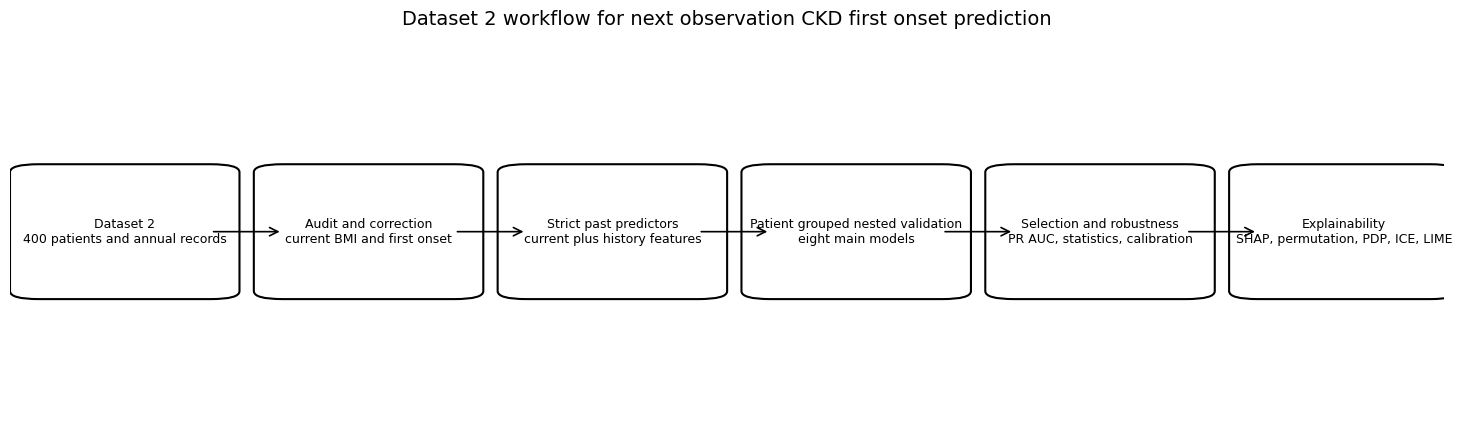

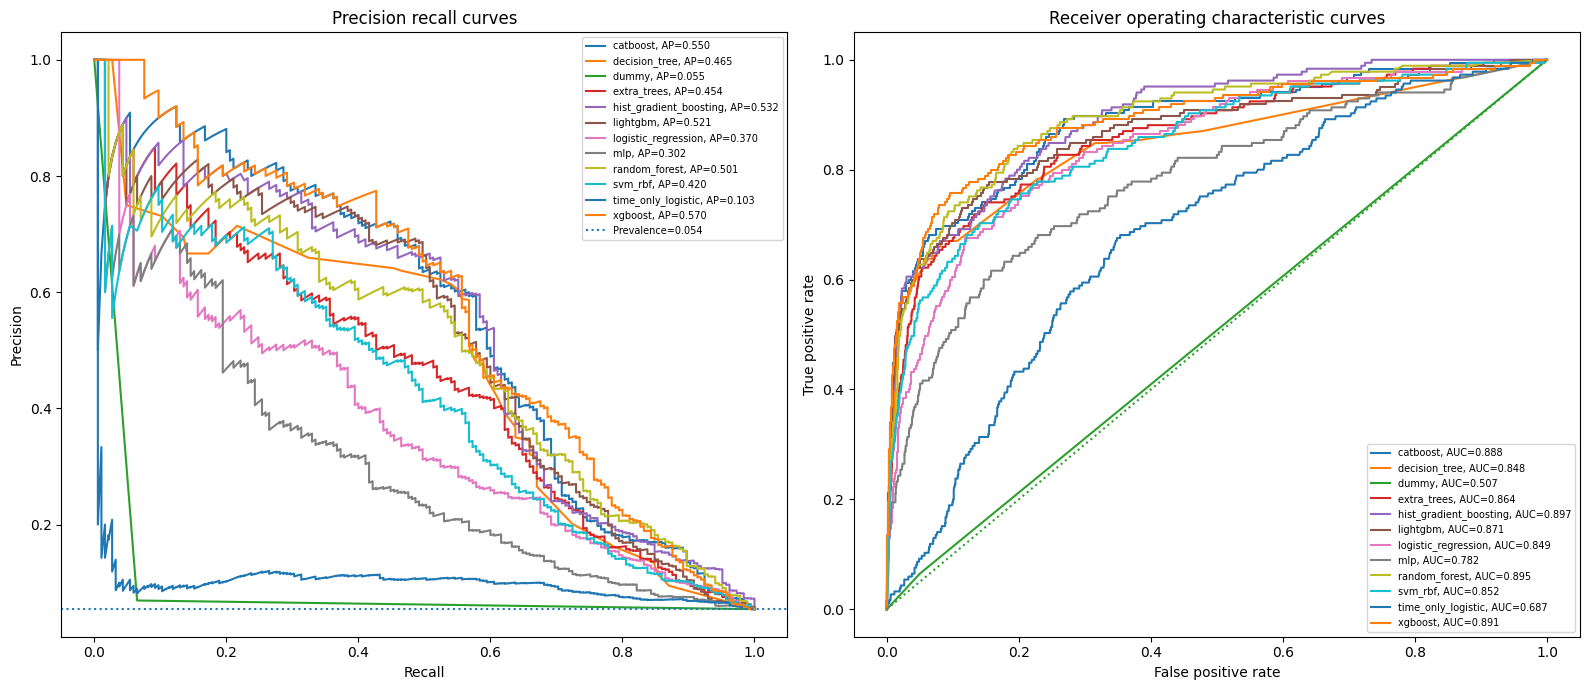

In [9]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, axis = plt.subplots(figsize=(15, 4.5))
axis.set_xlim(0, 1)
axis.set_ylim(0, 1)
axis.axis("off")
workflow_boxes = [
    (0.02, "Dataset 2\n400 patients and annual records"),
    (0.19, "Audit and correction\ncurrent BMI and first onset"),
    (0.36, "Strict past predictors\ncurrent plus history features"),
    (0.53, "Patient grouped nested validation\neight main models"),
    (0.70, "Selection and robustness\nPR AUC, statistics, calibration"),
    (0.87, "Explainability\nSHAP, permutation, PDP, ICE, LIME"),
]
for position, (x_value, label) in enumerate(workflow_boxes):
    box = FancyBboxPatch(
        (x_value, 0.35),
        0.12,
        0.30,
        boxstyle="round,pad=0.02",
        linewidth=1.5,
        fill=False,
    )
    axis.add_patch(box)
    axis.text(x_value + 0.06, 0.50, label, ha="center", va="center", fontsize=9)
    if position < len(workflow_boxes) - 1:
        arrow = FancyArrowPatch(
            (x_value + 0.12, 0.50),
            (workflow_boxes[position + 1][0], 0.50),
            arrowstyle="->",
            mutation_scale=15,
            linewidth=1.2,
        )
        axis.add_patch(arrow)
axis.set_title("Dataset 2 workflow for next observation CKD first onset prediction", fontsize=14)
fig.tight_layout()
fig.savefig(FIGURES / "01_dataset2_workflow.png", dpi=300, bbox_inches="tight")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for model_name, group in OOF_PREDICTIONS.groupby("model"):
    precision, recall, _ = precision_recall_curve(group["target"], group["probability"])
    score = average_precision_score(group["target"], group["probability"])
    axes[0].plot(recall, precision, label=f"{model_name}, AP={score:.3f}")
axes[0].axhline(
    model_data["target"].mean(),
    linestyle=":",
    label=f"Prevalence={model_data['target'].mean():.3f}",
)
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision recall curves")
axes[0].legend(fontsize=7)

for model_name, group in OOF_PREDICTIONS.groupby("model"):
    false_positive_rate, true_positive_rate, _ = roc_curve(group["target"], group["probability"])
    score = roc_auc_score(group["target"], group["probability"])
    axes[1].plot(false_positive_rate, true_positive_rate, label=f"{model_name}, AUC={score:.3f}")
axes[1].plot([0, 1], [0, 1], linestyle=":")
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")
axes[1].set_title("Receiver operating characteristic curves")
axes[1].legend(fontsize=7)
fig.tight_layout()
fig.savefig(FIGURES / "02_pr_and_roc_curves.png", dpi=300, bbox_inches="tight")


## Calibration and Confusion Matrix Analysis


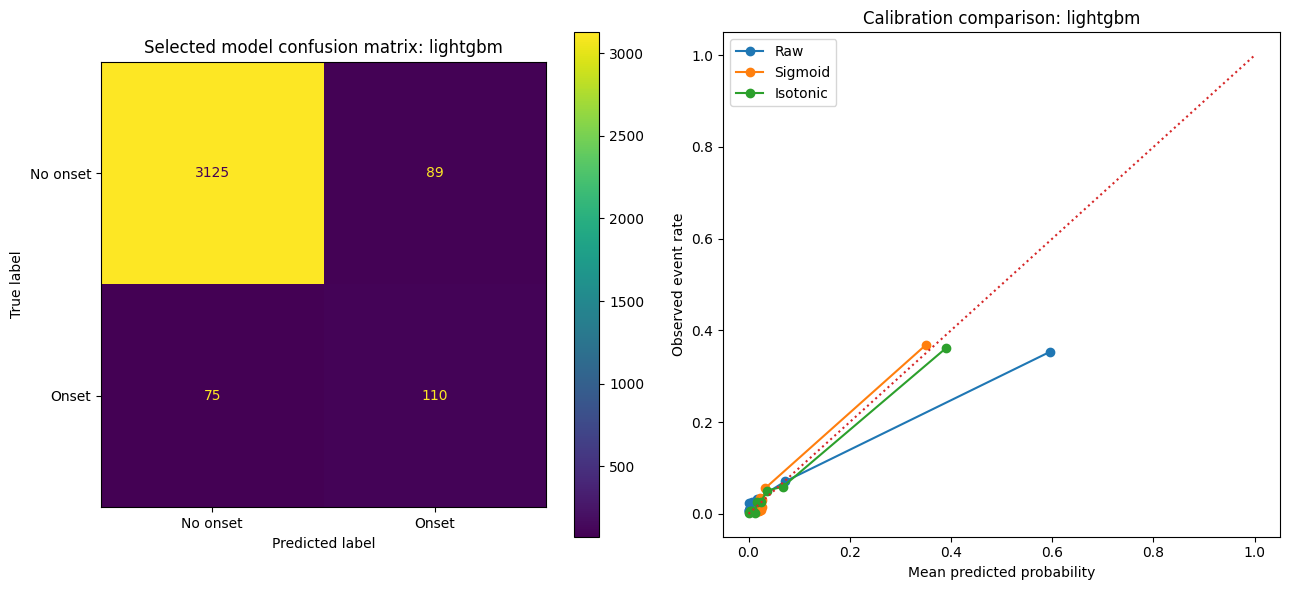

In [10]:
CALIBRATION_METRICS = pd.DataFrame()
CALIBRATION_SUMMARY = pd.DataFrame()
CALIBRATED_PREDICTIONS = pd.DataFrame()
CALIBRATION_SELECTION = "raw"


def calibration_slope_intercept(
    y_true: np.ndarray,
    probability: np.ndarray,
) -> Tuple[float, float]:
    transformed = logit(np.clip(probability, 1e-6, 1 - 1e-6)).reshape(-1, 1)
    model = LogisticRegression(penalty=None, solver="lbfgs", max_iter=2000)
    model.fit(transformed, y_true)
    return float(model.coef_[0, 0]), float(model.intercept_[0])


if RUN_CALIBRATION:
    metric_rows = []
    calibrated_parts = []

    for fold_number, (train_indices, test_indices) in enumerate(OUTER_SPLITS, start=1):
        train_frame = model_data.iloc[train_indices].reset_index(drop=True)
        test_frame = model_data.iloc[test_indices].reset_index(drop=True)

        parameter_text = BEST_PARAMETERS.loc[
            (BEST_PARAMETERS["model"] == SELECTED_MODEL)
            & (BEST_PARAMETERS["outer_fold"] == fold_number),
            "best_parameters",
        ].iloc[0]
        best_parameters = json.loads(parameter_text)

        estimator, _, model_features = build_estimator(
            SELECTED_MODEL,
            train_frame["target"].to_numpy(dtype=int),
            random_seed=PRIMARY_SEED + 7000 + fold_number,
            imbalance_strategy="class_weight",
        )
        estimator.set_params(**best_parameters)
        inner_splits = make_patient_splits(
            train_frame,
            INNER_FOLDS,
            PRIMARY_SEED + 8000 + fold_number,
        )

        probabilities = {}
        raw_fold = selected_predictions.loc[
            selected_predictions["outer_fold"] == fold_number
        ].sort_values("source_row_id")
        test_sorted = test_frame.sort_values("source_row_id")
        if not np.array_equal(
            raw_fold["source_row_id"].to_numpy(),
            test_sorted["source_row_id"].to_numpy(),
        ):
            raise AssertionError("Calibration row alignment failed.")
        probabilities["raw"] = raw_fold["probability"].to_numpy(dtype=float)

        for method in ["sigmoid", "isotonic"]:
            calibrator = CalibratedClassifierCV(
                estimator=estimator,
                method=method,
                cv=inner_splits,
                n_jobs=N_JOBS,
            )
            calibrator.fit(train_frame[model_features], train_frame["target"])
            probabilities[method] = calibrator.predict_proba(test_frame[model_features])[:, 1]

        y_true = test_sorted["target"].to_numpy(dtype=int)
        output = test_sorted[[
            "source_row_id", "patient_id", "visit_index", "diabetic_year", "target"
        ]].copy()
        output["outer_fold"] = fold_number

        for method, probability in probabilities.items():
            slope, intercept = calibration_slope_intercept(y_true, probability)
            metric_rows.append({
                "outer_fold": fold_number,
                "method": method,
                "pr_auc": average_precision_score(y_true, probability),
                "brier": brier_score_loss(y_true, probability),
                "ece10": expected_calibration_error(y_true, probability),
                "slope": slope,
                "intercept": intercept,
            })
            output[f"{method}_probability"] = probability
        calibrated_parts.append(output)

    CALIBRATION_METRICS = pd.DataFrame(metric_rows)
    CALIBRATED_PREDICTIONS = pd.concat(calibrated_parts, ignore_index=True)

    pooled_calibration_rows = []
    for method in ["raw", "sigmoid", "isotonic"]:
        probability = CALIBRATED_PREDICTIONS[f"{method}_probability"].to_numpy(dtype=float)
        y_true = CALIBRATED_PREDICTIONS["target"].to_numpy(dtype=int)
        slope, intercept = calibration_slope_intercept(y_true, probability)
        pooled_calibration_rows.append({
            "method": method,
            "pr_auc_oof": average_precision_score(y_true, probability),
            "brier_oof": brier_score_loss(y_true, probability),
            "ece10_oof": expected_calibration_error(y_true, probability),
            "slope_oof": slope,
            "intercept_oof": intercept,
        })
    CALIBRATION_SUMMARY = pd.DataFrame(pooled_calibration_rows).sort_values("brier_oof")
    raw_brier = float(CALIBRATION_SUMMARY.loc[CALIBRATION_SUMMARY["method"] == "raw", "brier_oof"].iloc[0])
    best_row = CALIBRATION_SUMMARY.iloc[0]
    if best_row["method"] != "raw" and float(best_row["brier_oof"]) < raw_brier * 0.99:
        CALIBRATION_SELECTION = str(best_row["method"])
    else:
        CALIBRATION_SELECTION = "raw"
    CALIBRATION_SUMMARY["selected_calibration"] = CALIBRATION_SUMMARY["method"] == CALIBRATION_SELECTION

    CALIBRATION_METRICS.to_csv(TABLES / "16_calibration_by_fold.csv", index=False)
    CALIBRATION_SUMMARY.to_csv(TABLES / "17_calibration_summary.csv", index=False)
    CALIBRATED_PREDICTIONS.to_csv(TABLES / "18_calibrated_predictions.csv", index=False)

    fig, axes = plt.subplots(1, 2, figsize=(13, 6))
    ConfusionMatrixDisplay.from_predictions(
        selected_predictions["target"],
        selected_predictions["prediction"],
        display_labels=["No onset", "Onset"],
        values_format="d",
        ax=axes[0],
    )
    axes[0].set_title(f"Selected model confusion matrix: {SELECTED_MODEL}")

    for method, label in [("raw", "Raw"), ("sigmoid", "Sigmoid"), ("isotonic", "Isotonic")]:
        observed, predicted = calibration_curve(
            CALIBRATED_PREDICTIONS["target"],
            CALIBRATED_PREDICTIONS[f"{method}_probability"],
            n_bins=10,
            strategy="quantile",
        )
        axes[1].plot(predicted, observed, marker="o", label=label)
    axes[1].plot([0, 1], [0, 1], linestyle=":")
    axes[1].set_xlabel("Mean predicted probability")
    axes[1].set_ylabel("Observed event rate")
    axes[1].set_title(f"Calibration comparison: {SELECTED_MODEL}")
    axes[1].legend()
    fig.tight_layout()
    fig.savefig(FIGURES / "03_confusion_and_calibration.png", dpi=300, bbox_inches="tight")

else:
    fig, axis = plt.subplots(figsize=(6, 6))
    ConfusionMatrixDisplay.from_predictions(
        selected_predictions["target"],
        selected_predictions["prediction"],
        display_labels=["No onset", "Onset"],
        values_format="d",
        ax=axis,
    )
    axis.set_title(f"Selected model: {SELECTED_MODEL}")
    fig.tight_layout()
    fig.savefig(FIGURES / "03_selected_confusion_matrix.png", dpi=300, bbox_inches="tight")


## Robustness and Imbalance Experiments


In [11]:
IMBALANCE_FOLD_METRICS = pd.DataFrame()
IMBALANCE_SUMMARY = pd.DataFrame()
RECORD_VALIDATION_METRICS = pd.DataFrame()
VALIDATION_SENSITIVITY = pd.DataFrame()
FEATURE_SENSITIVITY = pd.DataFrame()
SEED_STABILITY = pd.DataFrame()
LEARNING_CURVE_RESULTS = pd.DataFrame()

TOP_THREE_MODELS = (
    MODEL_SUMMARY.loc[MODEL_SUMMARY["eligible_for_selection"]]
    .sort_values("pr_auc_mean", ascending=False)
    .head(3)["model"]
    .tolist()
)

if RUN_ROBUSTNESS:
    imbalance_metric_parts = []
    for strategy in ["none", "class_weight", "smotenc"]:
        _, strategy_metrics, _ = evaluate_model_set(
            frame=model_data,
            outer_splits=OUTER_SPLITS,
            model_names=TOP_THREE_MODELS,
            run_seed=PRIMARY_SEED + 10000,
            output_tag=f"imbalance_{strategy}",
            imbalance_strategy=strategy,
            tune_override=ROBUSTNESS_TUNE_ITERATIONS,
            inner_split_mode="grouped",
            save_fitted_models=False,
        )
        imbalance_metric_parts.append(strategy_metrics)

    IMBALANCE_FOLD_METRICS = pd.concat(imbalance_metric_parts, ignore_index=True)
    IMBALANCE_SUMMARY = (
        IMBALANCE_FOLD_METRICS.groupby(["model", "imbalance_strategy"], as_index=False)
        .agg(
            pr_auc_mean=("pr_auc", "mean"),
            pr_auc_std=("pr_auc", "std"),
            f1_mean=("f1", "mean"),
            mcc_mean=("mcc", "mean"),
            sensitivity_mean=("sensitivity", "mean"),
            specificity_mean=("specificity", "mean"),
        )
        .sort_values(["model", "pr_auc_mean"], ascending=[True, False])
    )
    IMBALANCE_FOLD_METRICS.to_csv(SUPPLEMENTARY / "imbalance_fold_metrics.csv", index=False)
    IMBALANCE_SUMMARY.to_csv(TABLES / "19_imbalance_comparison.csv", index=False)
else:
    pass


## Validation Protocol and Feature Sensitivity Analysis


In [12]:
if RUN_ROBUSTNESS:
    record_outer_splits = make_record_splits(model_data, OUTER_FOLDS, PRIMARY_SEED)
    _, RECORD_VALIDATION_METRICS, _ = evaluate_model_set(
        frame=model_data,
        outer_splits=record_outer_splits,
        model_names=TOP_THREE_MODELS,
        run_seed=PRIMARY_SEED + 11000,
        output_tag="record_validation",
        imbalance_strategy="class_weight",
        tune_override=ROBUSTNESS_TUNE_ITERATIONS,
        inner_split_mode="record",
        save_fitted_models=False,
    )

    grouped_top = FOLD_METRICS.loc[FOLD_METRICS["model"].isin(TOP_THREE_MODELS)].copy()
    grouped_top["validation_protocol"] = "patient_grouped"
    record_top = RECORD_VALIDATION_METRICS.copy()
    record_top["validation_protocol"] = "record_level"
    VALIDATION_SENSITIVITY = (
        pd.concat([grouped_top, record_top], ignore_index=True)
        .groupby(["model", "validation_protocol"], as_index=False)
        .agg(
            pr_auc_mean=("pr_auc", "mean"),
            pr_auc_std=("pr_auc", "std"),
            roc_auc_mean=("roc_auc", "mean"),
            mcc_mean=("mcc", "mean"),
        )
    )

    current_predictions, current_metrics, _ = evaluate_model_set(
        frame=model_data,
        outer_splits=OUTER_SPLITS,
        model_names=[SELECTED_MODEL],
        run_seed=PRIMARY_SEED + 12000,
        output_tag="current_features_only",
        features_override=CURRENT_FEATURES,
        imbalance_strategy="class_weight",
        tune_override=ROBUSTNESS_TUNE_ITERATIONS,
        inner_split_mode="grouped",
        save_fitted_models=False,
    )

    stored_splits = make_patient_splits(model_data_stored_bmi, OUTER_FOLDS, PRIMARY_SEED)
    stored_predictions, stored_metrics, _ = evaluate_model_set(
        frame=model_data_stored_bmi,
        outer_splits=stored_splits,
        model_names=[SELECTED_MODEL],
        run_seed=PRIMARY_SEED + 13000,
        output_tag="stored_bmi",
        features_override=STORED_BMI_FEATURES,
        imbalance_strategy="class_weight",
        tune_override=ROBUSTNESS_TUNE_ITERATIONS,
        inner_split_mode="grouped",
        save_fitted_models=False,
    )

    full_selected_metrics = FOLD_METRICS.loc[FOLD_METRICS["model"] == SELECTED_MODEL].copy()
    feature_rows = []
    for label, metrics in [
        ("current_plus_history", full_selected_metrics),
        ("current_only", current_metrics),
        ("recalculated_bmi", full_selected_metrics),
        ("stored_bmi", stored_metrics),
    ]:
        feature_rows.append({
            "comparison": label,
            "model": SELECTED_MODEL,
            "pr_auc_mean": metrics["pr_auc"].mean(),
            "pr_auc_std": metrics["pr_auc"].std(),
            "roc_auc_mean": metrics["roc_auc"].mean(),
            "mcc_mean": metrics["mcc"].mean(),
        })
    FEATURE_SENSITIVITY = pd.DataFrame(feature_rows)

    VALIDATION_SENSITIVITY.to_csv(TABLES / "20_validation_sensitivity.csv", index=False)
    FEATURE_SENSITIVITY.to_csv(TABLES / "21_feature_sensitivity.csv", index=False)
    current_predictions.to_csv(SUPPLEMENTARY / "current_only_oof_predictions.csv", index=False)
    stored_predictions.to_csv(SUPPLEMENTARY / "stored_bmi_oof_predictions.csv", index=False)



## Learning Curves, Seed Stability, and Statistical Tests


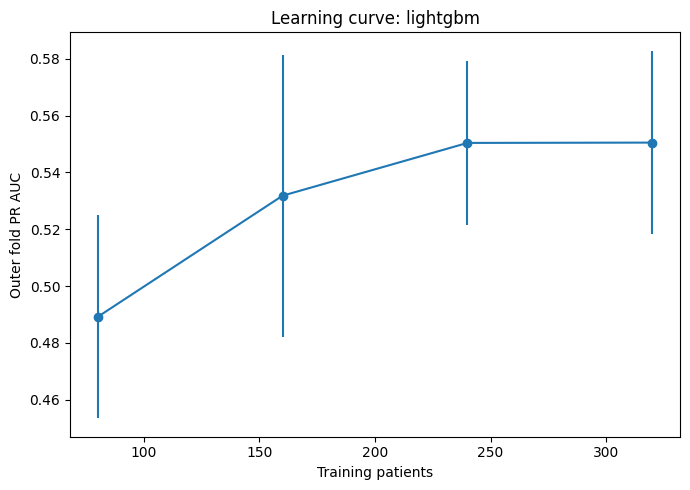

In [13]:
def sample_training_patients(
    train_frame: pd.DataFrame,
    fraction: float,
    seed: int,
) -> pd.DataFrame:
    if fraction >= 1.0:
        return train_frame.copy()
    patients = (
        train_frame[["patient_id"]]
        .drop_duplicates()
        .merge(patient_strata, on="patient_id", how="left")
    )
    patients["binary_stratum"] = np.where(patients["onset_stratum"] == "never", "never", "ever")
    sampled_parts = []
    rng = np.random.default_rng(seed)
    for _, group in patients.groupby("binary_stratum"):
        count = max(1, int(round(len(group) * fraction)))
        chosen_positions = rng.choice(len(group), size=min(count, len(group)), replace=False)
        sampled_parts.append(group.iloc[chosen_positions])
    chosen_patients = pd.concat(sampled_parts, ignore_index=True)["patient_id"]
    return train_frame.loc[train_frame["patient_id"].isin(chosen_patients)].copy()


if RUN_LEARNING_CURVES:
    learning_rows = []
    fractions = [0.25, 0.50, 0.75, 1.00]
    for fold_number, (train_indices, test_indices) in enumerate(OUTER_SPLITS, start=1):
        train_frame = model_data.iloc[train_indices].reset_index(drop=True)
        test_frame = model_data.iloc[test_indices].reset_index(drop=True)
        parameter_text = BEST_PARAMETERS.loc[
            (BEST_PARAMETERS["model"] == SELECTED_MODEL)
            & (BEST_PARAMETERS["outer_fold"] == fold_number),
            "best_parameters",
        ].iloc[0]
        best_parameters = json.loads(parameter_text)

        for fraction in fractions:
            subset = sample_training_patients(
                train_frame,
                fraction,
                PRIMARY_SEED + fold_number + int(fraction * 1000),
            )
            estimator, _, model_features = build_estimator(
                SELECTED_MODEL,
                subset["target"].to_numpy(dtype=int),
                random_seed=PRIMARY_SEED + 14000 + fold_number,
                imbalance_strategy="class_weight",
            )
            estimator.set_params(**best_parameters)
            estimator.fit(subset[model_features], subset["target"])
            probability = predict_probability(estimator, test_frame[model_features])
            learning_rows.append({
                "outer_fold": fold_number,
                "training_fraction": fraction,
                "training_patients": subset["patient_id"].nunique(),
                "training_examples": len(subset),
                "pr_auc": average_precision_score(test_frame["target"], probability),
                "roc_auc": roc_auc_score(test_frame["target"], probability),
            })

    LEARNING_CURVE_RESULTS = pd.DataFrame(learning_rows)
    LEARNING_CURVE_RESULTS.to_csv(TABLES / "22_learning_curve_results.csv", index=False)
    learning_summary = (
        LEARNING_CURVE_RESULTS.groupby("training_fraction", as_index=False)
        .agg(
            training_patients=("training_patients", "mean"),
            pr_auc_mean=("pr_auc", "mean"),
            pr_auc_std=("pr_auc", "std"),
            roc_auc_mean=("roc_auc", "mean"),
        )
    )
    fig, axis = plt.subplots(figsize=(7, 5))
    axis.errorbar(
        learning_summary["training_patients"],
        learning_summary["pr_auc_mean"],
        yerr=learning_summary["pr_auc_std"],
        marker="o",
    )
    axis.set_xlabel("Training patients")
    axis.set_ylabel("Outer fold PR AUC")
    axis.set_title(f"Learning curve: {SELECTED_MODEL}")
    fig.tight_layout()
    fig.savefig(FIGURES / "07_learning_curve.png", dpi=300, bbox_inches="tight")
else:
    pass


SEED_FOLD_METRICS = FOLD_METRICS.copy()
SEED_FOLD_METRICS["evaluation_seed"] = PRIMARY_SEED
SEED_STABILITY_PARAMETERS = BEST_PARAMETERS.copy()
SEED_STABILITY_PARAMETERS["evaluation_seed"] = PRIMARY_SEED
SEED_STABILITY_OVERALL = pd.DataFrame()
WILCOXON_TESTS = pd.DataFrame()

if RUN_SEED_STABILITY:
    seed_metric_parts = []
    seed_parameter_parts = []

    primary_all = FOLD_METRICS.loc[FOLD_METRICS["model"].isin(MODEL_NAMES)].copy()
    primary_all["evaluation_seed"] = PRIMARY_SEED
    seed_metric_parts.append(primary_all)

    primary_parameters = BEST_PARAMETERS.loc[BEST_PARAMETERS["model"].isin(MODEL_NAMES)].copy()
    primary_parameters["evaluation_seed"] = PRIMARY_SEED
    seed_parameter_parts.append(primary_parameters)

    for seed in [value for value in STABILITY_SEEDS if value != PRIMARY_SEED]:
        seed_splits = make_patient_splits(model_data, OUTER_FOLDS, seed)
        _, seed_metrics, seed_parameters = evaluate_model_set(
            frame=model_data,
            outer_splits=seed_splits,
            model_names=MODEL_NAMES,
            run_seed=seed,
            output_tag=f"seed_{seed}",
            imbalance_strategy="class_weight",
            tune_override=None,
            inner_split_mode="grouped",
            save_fitted_models=False,
        )
        seed_metrics["evaluation_seed"] = seed
        seed_parameters["evaluation_seed"] = seed
        seed_metric_parts.append(seed_metrics)
        seed_parameter_parts.append(seed_parameters)

    SEED_FOLD_METRICS = pd.concat(seed_metric_parts, ignore_index=True)
    SEED_STABILITY_PARAMETERS = pd.concat(seed_parameter_parts, ignore_index=True)
    SEED_STABILITY = (
        SEED_FOLD_METRICS.groupby(["model", "evaluation_seed"], as_index=False)
        .agg(
            pr_auc_mean=("pr_auc", "mean"),
            pr_auc_std=("pr_auc", "std"),
            roc_auc_mean=("roc_auc", "mean"),
            roc_auc_std=("roc_auc", "std"),
            mcc_mean=("mcc", "mean"),
            mcc_std=("mcc", "std"),
        )
    )
    SEED_STABILITY_OVERALL = (
        SEED_FOLD_METRICS.groupby("model", as_index=False)
        .agg(
            observations=("pr_auc", "size"),
            seeds=("evaluation_seed", "nunique"),
            pr_auc_mean=("pr_auc", "mean"),
            pr_auc_std=("pr_auc", "std"),
            roc_auc_mean=("roc_auc", "mean"),
            roc_auc_std=("roc_auc", "std"),
            mcc_mean=("mcc", "mean"),
            mcc_std=("mcc", "std"),
        )
        .sort_values("pr_auc_mean", ascending=False)
    )

    SEED_FOLD_METRICS.to_csv(SUPPLEMENTARY / "seed_stability_fold_metrics.csv", index=False)
    SEED_STABILITY_PARAMETERS.to_csv(SUPPLEMENTARY / "seed_stability_best_parameters.csv", index=False)
    SEED_STABILITY.to_csv(TABLES / "23_seed_stability.csv", index=False)
    SEED_STABILITY_OVERALL.to_csv(TABLES / "23b_seed_stability_overall.csv", index=False)
else:
    pass

# Supplementary paired Wilcoxon tests. Patient bootstrap remains the primary statistical method.
wilcoxon_rows = []
selected_seed_scores = SEED_FOLD_METRICS.loc[
    SEED_FOLD_METRICS["model"] == SELECTED_MODEL,
    ["evaluation_seed", "outer_fold", "pr_auc", "roc_auc", "mcc"],
].copy()

for comparator in MODEL_NAMES:
    if comparator == SELECTED_MODEL:
        continue
    comparator_scores = SEED_FOLD_METRICS.loc[
        SEED_FOLD_METRICS["model"] == comparator,
        ["evaluation_seed", "outer_fold", "pr_auc", "roc_auc", "mcc"],
    ].copy()
    paired = selected_seed_scores.merge(
        comparator_scores,
        on=["evaluation_seed", "outer_fold"],
        how="inner",
        suffixes=("_selected", "_comparator"),
    )
    if paired.empty:
        continue

    row = {
        "selected_model": SELECTED_MODEL,
        "comparator_model": comparator,
        "n_paired_results": len(paired),
        "seeds": int(paired["evaluation_seed"].nunique()),
    }
    for metric in ["pr_auc", "roc_auc", "mcc"]:
        selected_values = paired[f"{metric}_selected"].to_numpy(dtype=float)
        comparator_values = paired[f"{metric}_comparator"].to_numpy(dtype=float)
        differences = selected_values - comparator_values
        if np.allclose(differences, 0):
            statistic, p_value = 0.0, 1.0
        else:
            statistic, p_value = wilcoxon(
                selected_values,
                comparator_values,
                alternative="two-sided",
                zero_method="wilcox",
                mode="auto",
            )
        row[f"{metric}_selected_mean"] = float(np.mean(selected_values))
        row[f"{metric}_comparator_mean"] = float(np.mean(comparator_values))
        row[f"{metric}_mean_difference"] = float(np.mean(differences))
        row[f"{metric}_wilcoxon_statistic"] = float(statistic)
        row[f"{metric}_wilcoxon_p"] = float(p_value)
    wilcoxon_rows.append(row)

WILCOXON_TESTS = pd.DataFrame(wilcoxon_rows)
WILCOXON_TESTS.to_csv(SUPPLEMENTARY / "supp_statistical_tests.csv", index=False)


## Permutation Feature Importance Analysis


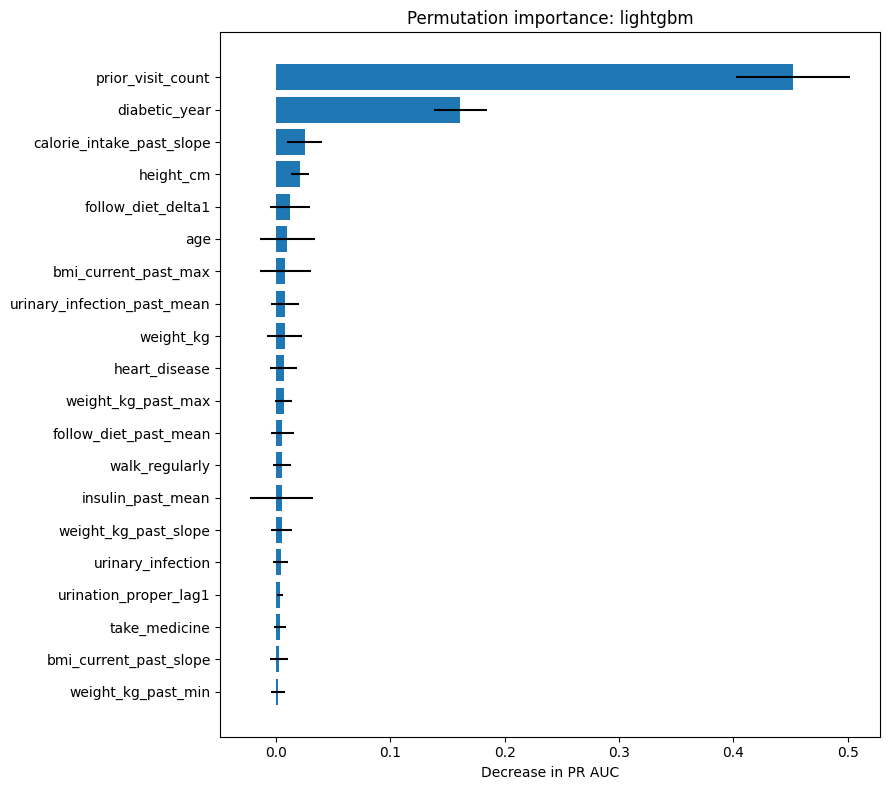

In [14]:
PERMUTATION_FOLD = pd.DataFrame()
PERMUTATION_SUMMARY = pd.DataFrame()
PERMUTATION_FAMILY_SUMMARY = pd.DataFrame()
permutation_rows = []

for fold_number, (_, test_indices) in enumerate(OUTER_SPLITS, start=1):
    test_frame = model_data.iloc[test_indices].reset_index(drop=True)
    estimator = joblib.load(MODELS / f"{SELECTED_MODEL}_fold_{fold_number}.joblib")
    _, _, model_features = build_estimator(
        SELECTED_MODEL,
        test_frame["target"].to_numpy(dtype=int),
        random_seed=PRIMARY_SEED,
        imbalance_strategy="class_weight",
    )

    result = permutation_importance(
        estimator,
        test_frame[model_features],
        test_frame["target"],
        scoring="average_precision",
        n_repeats=PERMUTATION_REPEATS,
        random_state=PRIMARY_SEED + fold_number,
        n_jobs=N_JOBS,
    )

    for feature, mean_value, std_value in zip(
        model_features,
        result.importances_mean,
        result.importances_std,
    ):
        permutation_rows.append({
            "outer_fold": fold_number,
            "feature": feature,
            "feature_family": feature_family(feature),
            "importance_mean": mean_value,
            "importance_std": std_value,
        })

PERMUTATION_FOLD = pd.DataFrame(permutation_rows)
PERMUTATION_SUMMARY = (
    PERMUTATION_FOLD.groupby(["feature", "feature_family"], as_index=False)
    .agg(
        mean_importance=("importance_mean", "mean"),
        std_importance=("importance_mean", "std"),
        positive_fold_frequency=("importance_mean", lambda values: np.mean(np.asarray(values) > 0)),
    )
    .sort_values("mean_importance", ascending=False)
)
PERMUTATION_SUMMARY["permutation_rank"] = PERMUTATION_SUMMARY["mean_importance"].rank(
    ascending=False,
    method="min",
)
PERMUTATION_FAMILY_SUMMARY = (
    PERMUTATION_FOLD.groupby(["outer_fold", "feature_family"], as_index=False)["importance_mean"].sum()
    .groupby("feature_family", as_index=False)
    .agg(
        mean_importance=("importance_mean", "mean"),
        std_importance=("importance_mean", "std"),
    )
    .sort_values("mean_importance", ascending=False)
)

PERMUTATION_FOLD.to_csv(TABLES / "24_permutation_by_fold.csv", index=False)
PERMUTATION_SUMMARY.to_csv(TABLES / "25_permutation_summary.csv", index=False)
PERMUTATION_FAMILY_SUMMARY.to_csv(TABLES / "26_permutation_family_summary.csv", index=False)

plot_data = PERMUTATION_SUMMARY.head(20).sort_values("mean_importance")
fig, axis = plt.subplots(figsize=(9, 8))
axis.barh(
    plot_data["feature"],
    plot_data["mean_importance"],
    xerr=plot_data["std_importance"].fillna(0),
)
axis.set_xlabel("Decrease in PR AUC")
axis.set_title(f"Permutation importance: {SELECTED_MODEL}")
fig.tight_layout()
fig.savefig(FIGURES / "04_permutation_importance.png", dpi=300, bbox_inches="tight")



## SHAP Global Explainability and Stability Analysis


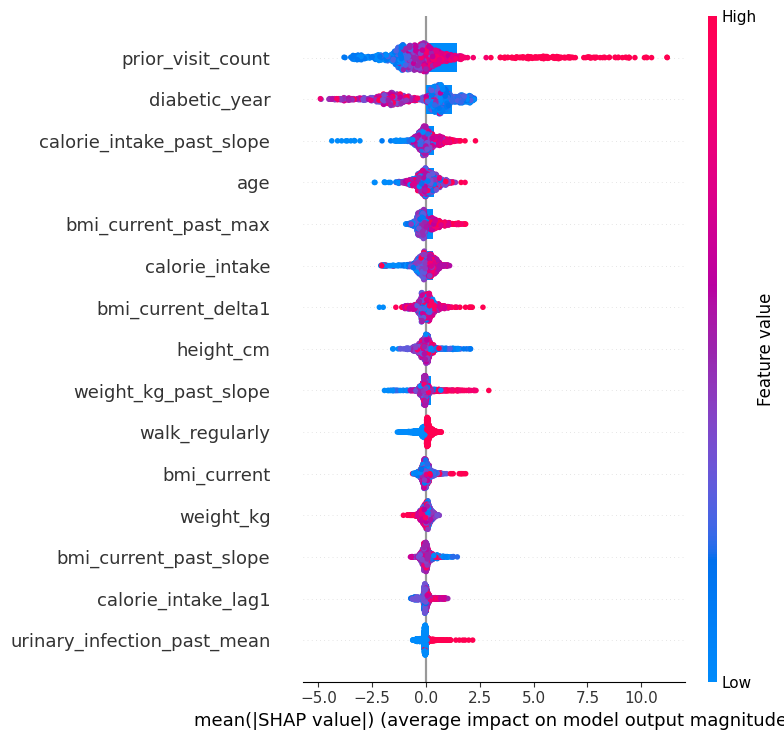

In [15]:
SHAP_FOLD = pd.DataFrame()
SHAP_SUMMARY = pd.DataFrame()
SHAP_FAMILY_SUMMARY = pd.DataFrame()
EXPLANATION_AGREEMENT = pd.DataFrame()
SHAP_ALL_VALUES = None
SHAP_ALL_DATA = None
SHAP_FEATURE_NAMES = None


def transformed_tree_data(estimator: Pipeline, X: pd.DataFrame) -> np.ndarray:
    if "preprocess" in estimator.named_steps:
        return np.asarray(estimator.named_steps["preprocess"].transform(X))
    if "imputer" in estimator.named_steps:
        transformed = estimator.named_steps["imputer"].transform(X)
        if "scaler" in estimator.named_steps and estimator.named_steps["scaler"] != "passthrough":
            transformed = estimator.named_steps["scaler"].transform(transformed)
        return np.asarray(transformed)
    raise KeyError("A supported preprocessing step was not found.")


def positive_class_shap(values: Any) -> np.ndarray:
    if isinstance(values, list):
        values = values[-1]
    values = np.asarray(values)
    if values.ndim == 3:
        values = values[:, :, -1]
    return values


if RUN_SHAP and SELECTED_MODEL in TREE_MODELS:
    try:
        import shap

        fold_rows = []
        all_values = []
        all_data = []
        model_features = None

        for fold_number, (_, test_indices) in enumerate(OUTER_SPLITS, start=1):
            test_frame = model_data.iloc[test_indices].reset_index(drop=True)
            sample = test_frame.sample(
                n=min(250, len(test_frame)),
                random_state=PRIMARY_SEED + fold_number,
            )
            estimator = joblib.load(MODELS / f"{SELECTED_MODEL}_fold_{fold_number}.joblib")
            _, _, model_features = build_estimator(
                SELECTED_MODEL,
                test_frame["target"].to_numpy(dtype=int),
                random_seed=PRIMARY_SEED,
                imbalance_strategy="class_weight",
            )

            transformed = transformed_tree_data(estimator, sample[model_features])
            model = estimator.named_steps["model"]
            explainer = shap.TreeExplainer(model)
            values = positive_class_shap(explainer.shap_values(transformed))

            all_values.append(values)
            all_data.append(transformed)

            mean_abs = np.mean(np.abs(values), axis=0)
            ranks = pd.Series(mean_abs, index=model_features).rank(ascending=False, method="min")
            for feature, importance in zip(model_features, mean_abs):
                fold_rows.append({
                    "outer_fold": fold_number,
                    "feature": feature,
                    "feature_family": feature_family(feature),
                    "mean_abs_shap": importance,
                    "rank": ranks.loc[feature],
                })

        SHAP_FOLD = pd.DataFrame(fold_rows)
        SHAP_SUMMARY = (
            SHAP_FOLD.groupby(["feature", "feature_family"], as_index=False)
            .agg(
                mean_abs_shap=("mean_abs_shap", "mean"),
                std_abs_shap=("mean_abs_shap", "std"),
                median_rank=("rank", "median"),
                top_ten_frequency=("rank", lambda values: np.mean(np.asarray(values) <= 10)),
            )
            .sort_values("mean_abs_shap", ascending=False)
        )
        SHAP_SUMMARY["shap_rank"] = SHAP_SUMMARY["mean_abs_shap"].rank(
            ascending=False,
            method="min",
        )

        SHAP_FAMILY_SUMMARY = (
            SHAP_FOLD.groupby(["outer_fold", "feature_family"], as_index=False)["mean_abs_shap"].sum()
            .groupby("feature_family", as_index=False)
            .agg(
                mean_abs_shap=("mean_abs_shap", "mean"),
                std_abs_shap=("mean_abs_shap", "std"),
            )
            .sort_values("mean_abs_shap", ascending=False)
        )
        SHAP_FAMILY_SUMMARY["family_rank"] = SHAP_FAMILY_SUMMARY["mean_abs_shap"].rank(
            ascending=False,
            method="min",
        )

        agreement = SHAP_SUMMARY.merge(
            PERMUTATION_SUMMARY[["feature", "mean_importance", "permutation_rank"]],
            on="feature",
            how="inner",
        )
        correlation, correlation_p = spearmanr(
            agreement["shap_rank"],
            agreement["permutation_rank"],
        )
        shap_top_ten = set(SHAP_SUMMARY.head(10)["feature"])
        permutation_top_ten = set(PERMUTATION_SUMMARY.head(10)["feature"])
        overlap = shap_top_ten & permutation_top_ten
        agreement["top_ten_in_both"] = agreement["feature"].isin(overlap)
        agreement["spearman_correlation_all_features"] = correlation
        agreement["spearman_p_all_features"] = correlation_p
        agreement["top_ten_overlap_count"] = len(overlap)
        agreement["top_ten_jaccard"] = len(overlap) / len(shap_top_ten | permutation_top_ten)
        EXPLANATION_AGREEMENT = agreement.sort_values("shap_rank")

        SHAP_FOLD.to_csv(TABLES / "27_shap_by_fold.csv", index=False)
        SHAP_SUMMARY.to_csv(TABLES / "28_shap_stability.csv", index=False)
        SHAP_FAMILY_SUMMARY.to_csv(TABLES / "29_shap_family_stability.csv", index=False)
        EXPLANATION_AGREEMENT.to_csv(TABLES / "30_shap_permutation_agreement.csv", index=False)

        SHAP_ALL_VALUES = np.vstack(all_values)
        SHAP_ALL_DATA = np.vstack(all_data)
        SHAP_FEATURE_NAMES = model_features

        shap.summary_plot(
            SHAP_ALL_VALUES,
            SHAP_ALL_DATA,
            feature_names=SHAP_FEATURE_NAMES,
            max_display=15,
            show=False,
        )
        plt.tight_layout()
        plt.savefig(FIGURES / "05_shap_beeswarm.png", dpi=300, bbox_inches="tight")

        shap.summary_plot(
            SHAP_ALL_VALUES,
            SHAP_ALL_DATA,
            feature_names=SHAP_FEATURE_NAMES,
            plot_type="bar",
            max_display=15,
            show=False,
        )
        plt.tight_layout()
        plt.savefig(FIGURES / "06_shap_mean_importance.png", dpi=300, bbox_inches="tight")


    except Exception as error:
        pass
else:
    pass


## Final Model Training and PDP ICE Analysis


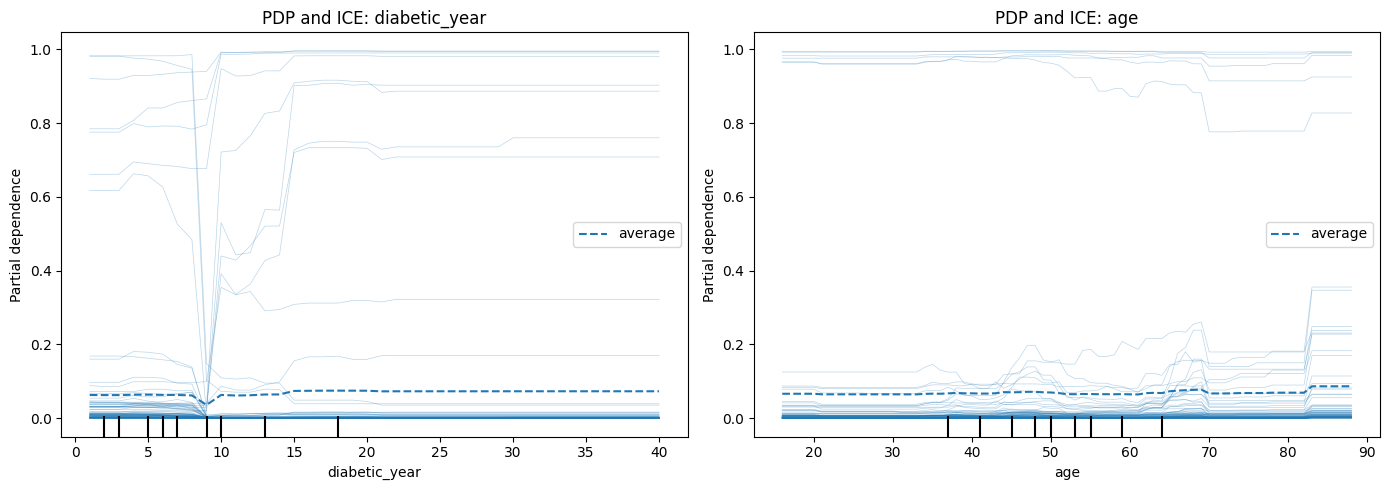

In [16]:
FINAL_MODEL = None
FINAL_MODEL_FEATURES = FEATURES
PDP_FEATURES = []

selected_fold_metrics = FOLD_METRICS.loc[FOLD_METRICS["model"] == SELECTED_MODEL].copy()
if selected_fold_metrics["inner_pr_auc"].notna().any():
    best_parameter_fold = int(
        selected_fold_metrics.sort_values("inner_pr_auc", ascending=False).iloc[0]["outer_fold"]
    )
else:
    best_parameter_fold = 1
selected_parameter_text = BEST_PARAMETERS.loc[
    (BEST_PARAMETERS["model"] == SELECTED_MODEL)
    & (BEST_PARAMETERS["outer_fold"] == best_parameter_fold),
    "best_parameters",
].iloc[0]
selected_parameters = json.loads(selected_parameter_text)

FINAL_MODEL, _, FINAL_MODEL_FEATURES = build_estimator(
    SELECTED_MODEL,
    model_data["target"].to_numpy(dtype=int),
    random_seed=PRIMARY_SEED + 15000,
    imbalance_strategy="class_weight",
)
FINAL_MODEL.set_params(**selected_parameters)
FINAL_MODEL.fit(model_data[FINAL_MODEL_FEATURES], model_data["target"])
joblib.dump(FINAL_MODEL, MODELS / "selected_model_refit_full_dataset.joblib")

candidate_effect_features = [
    feature for feature in ["diabetic_year", "age", "bmi_current", "calorie_intake"]
    if feature in FINAL_MODEL_FEATURES
]
if not SHAP_SUMMARY.empty:
    ranked_candidates = (
        SHAP_SUMMARY.loc[SHAP_SUMMARY["feature"].isin(candidate_effect_features)]
        .sort_values("mean_abs_shap", ascending=False)["feature"]
        .tolist()
    )
    PDP_FEATURES = ranked_candidates[:2]
else:
    PDP_FEATURES = candidate_effect_features[:2]

if PDP_FEATURES:
    fig, axes = plt.subplots(1, len(PDP_FEATURES), figsize=(7 * len(PDP_FEATURES), 5))
    if len(PDP_FEATURES) == 1:
        axes = [axes]
    for axis, feature in zip(axes, PDP_FEATURES):
        PartialDependenceDisplay.from_estimator(
            FINAL_MODEL,
            model_data[FINAL_MODEL_FEATURES],
            [feature],
            kind="both",
            subsample=min(100, len(model_data)),
            random_state=PRIMARY_SEED,
            ax=axis,
        )
        axis.set_title(f"PDP and ICE: {feature}")
    fig.tight_layout()
    fig.savefig(FIGURES / "08_pdp_and_ice.png", dpi=300, bbox_inches="tight")
else:
    pass


## Local SHAP and LIME Explanation Analysis


In [17]:
LOCAL_CASES = pd.DataFrame()
LOCAL_SHAP = pd.DataFrame()
LOCAL_LIME = pd.DataFrame()
LOCAL_AGREEMENT = pd.DataFrame()


def select_representative_case(frame: pd.DataFrame, target_value: int, prediction_value: int) -> Optional[pd.Series]:
    candidates = frame.loc[
        (frame["target"] == target_value)
        & (frame["prediction"] == prediction_value)
    ].copy()
    if candidates.empty:
        return None
    median_probability = candidates["probability"].median()
    candidates["distance_to_median_probability"] = (
        candidates["probability"] - median_probability
    ).abs()
    return candidates.sort_values("distance_to_median_probability").iloc[0]


if RUN_SHAP and SELECTED_MODEL in TREE_MODELS and not SHAP_SUMMARY.empty:
    try:
        import shap

        case_definitions = [
            ("true_positive", 1, 1),
            ("false_negative", 1, 0),
        ]
        case_rows = []
        local_shap_rows = []
        local_lime_rows = []
        local_agreement_rows = []

        for case_label, target_value, prediction_value in case_definitions:
            case = select_representative_case(selected_predictions, target_value, prediction_value)
            if case is None:
                continue

            fold_number = int(case["outer_fold"])
            source_row_id = int(case["source_row_id"])
            row = model_data.loc[model_data["source_row_id"] == source_row_id].iloc[[0]]
            train_indices, _ = OUTER_SPLITS[fold_number - 1]
            train_frame = model_data.iloc[train_indices].reset_index(drop=True)
            estimator = joblib.load(MODELS / f"{SELECTED_MODEL}_fold_{fold_number}.joblib")
            _, _, model_features = build_estimator(
                SELECTED_MODEL,
                train_frame["target"].to_numpy(dtype=int),
                random_seed=PRIMARY_SEED,
                imbalance_strategy="class_weight",
            )

            transformed_row = transformed_tree_data(estimator, row[model_features])
            model = estimator.named_steps["model"]
            explainer = shap.TreeExplainer(model)
            values = positive_class_shap(explainer.shap_values(transformed_row))[0]
            expected = explainer.expected_value
            if isinstance(expected, (list, tuple, np.ndarray)):
                expected_array = np.asarray(expected).reshape(-1)
                expected = expected_array[-1]

            explanation = shap.Explanation(
                values=values,
                base_values=float(expected),
                data=transformed_row[0],
                feature_names=model_features,
            )
            shap.plots.waterfall(explanation, max_display=15, show=False)
            plt.title(f"Local SHAP: {case_label}")
            plt.tight_layout()
            plt.savefig(
                FIGURES / f"09_local_shap_{case_label}.png",
                dpi=300,
                bbox_inches="tight",
            )

            shap_case = pd.DataFrame({
                "case": case_label,
                "source_row_id": source_row_id,
                "patient_id": case["patient_id"],
                "outer_fold": fold_number,
                "feature": model_features,
                "feature_value_after_preprocessing": transformed_row[0],
                "shap_value": values,
            })
            shap_case["absolute_shap"] = shap_case["shap_value"].abs()
            shap_case["direction"] = np.where(shap_case["shap_value"] >= 0, "supports_onset", "opposes_onset")
            local_shap_rows.append(shap_case)

            case_rows.append({
                "case": case_label,
                "source_row_id": source_row_id,
                "patient_id": case["patient_id"],
                "outer_fold": fold_number,
                "target": int(case["target"]),
                "prediction": int(case["prediction"]),
                "probability": float(case["probability"]),
                "threshold": float(case["threshold"]),
            })

            if RUN_LIME:
                try:
                    from lime.lime_tabular import LimeTabularExplainer

                    training_raw = train_frame[model_features].copy()
                    medians = training_raw.median(numeric_only=True)
                    training_imputed = training_raw.fillna(medians).to_numpy(dtype=float)
                    row_imputed = row[model_features].fillna(medians).to_numpy(dtype=float)[0]

                    def lime_predict(array: np.ndarray) -> np.ndarray:
                        prediction_frame = pd.DataFrame(array, columns=model_features)
                        return estimator.predict_proba(prediction_frame)

                    lime_explainer = LimeTabularExplainer(
                        training_data=training_imputed,
                        feature_names=model_features,
                        class_names=["No onset", "Onset"],
                        mode="classification",
                        discretize_continuous=True,
                        random_state=PRIMARY_SEED + fold_number,
                    )
                    lime_explanation = lime_explainer.explain_instance(
                        row_imputed,
                        lime_predict,
                        num_features=min(15, len(model_features)),
                        labels=[1],
                    )
                    lime_explanation.save_to_file(
                        str(REPORTS / f"lime_{case_label}.html")
                    )
                    lime_figure = lime_explanation.as_pyplot_figure(label=1)
                    lime_figure.suptitle(f"Local LIME: {case_label}")
                    lime_figure.tight_layout()
                    lime_figure.savefig(
                        FIGURES / f"09_local_lime_{case_label}.png",
                        dpi=300,
                        bbox_inches="tight",
                    )
                    plt.close(lime_figure)
                    mapping = lime_explanation.as_map()[1]
                    lime_case = pd.DataFrame([
                        {
                            "case": case_label,
                            "source_row_id": source_row_id,
                            "patient_id": case["patient_id"],
                            "outer_fold": fold_number,
                            "feature": model_features[feature_index],
                            "lime_weight": weight,
                            "absolute_lime": abs(weight),
                            "direction": "supports_onset" if weight >= 0 else "opposes_onset",
                        }
                        for feature_index, weight in mapping
                    ])
                    local_lime_rows.append(lime_case)

                    shap_top = shap_case.sort_values("absolute_shap", ascending=False).head(10)
                    lime_top = lime_case.sort_values("absolute_lime", ascending=False).head(10)
                    common = shap_top.merge(
                        lime_top,
                        on="feature",
                        how="inner",
                        suffixes=("_shap", "_lime"),
                    )
                    sign_agreement = float(
                        np.mean(np.sign(common["shap_value"]) == np.sign(common["lime_weight"]))
                    ) if len(common) else np.nan
                    local_agreement_rows.append({
                        "case": case_label,
                        "source_row_id": source_row_id,
                        "top_ten_overlap_count": len(common),
                        "top_ten_jaccard": len(common) / len(set(shap_top["feature"]) | set(lime_top["feature"])),
                        "sign_agreement_for_common_features": sign_agreement,
                    })
                except Exception as lime_error:
                    pass

        LOCAL_CASES = pd.DataFrame(case_rows)
        LOCAL_SHAP = pd.concat(local_shap_rows, ignore_index=True) if local_shap_rows else pd.DataFrame()
        LOCAL_LIME = pd.concat(local_lime_rows, ignore_index=True) if local_lime_rows else pd.DataFrame()
        LOCAL_AGREEMENT = pd.DataFrame(local_agreement_rows)

        LOCAL_CASES.to_csv(TABLES / "31_local_case_summary.csv", index=False)
        LOCAL_SHAP.to_csv(TABLES / "32_local_shap_values.csv", index=False)
        LOCAL_LIME.to_csv(TABLES / "33_local_lime_values.csv", index=False)
        LOCAL_AGREEMENT.to_csv(TABLES / "34_local_shap_lime_agreement.csv", index=False)

        # Publication figure combining SHAP and LIME for the same representative cases.
        combined_paths = [
            ("True positive SHAP", FIGURES / "09_local_shap_true_positive.png"),
            ("True positive LIME", FIGURES / "09_local_lime_true_positive.png"),
            ("False negative SHAP", FIGURES / "09_local_shap_false_negative.png"),
            ("False negative LIME", FIGURES / "09_local_lime_false_negative.png"),
        ]
        combined_figure, combined_axes = plt.subplots(2, 2, figsize=(18, 14))
        for combined_axis, (combined_title, combined_path) in zip(combined_axes.ravel(), combined_paths):
            combined_axis.axis("off")
            combined_axis.set_title(combined_title)
            if combined_path.exists():
                combined_axis.imshow(plt.imread(combined_path))
            else:
                combined_axis.text(0.5, 0.5, "Output unavailable", ha="center", va="center")
        combined_figure.tight_layout()
        combined_figure.savefig(
            FIGURES / "figure6_local_explanations.png",
            dpi=300,
            bbox_inches="tight",
        )

    except Exception as error:
        pass
else:
    pass


## SHAP Interaction Analysis


In [18]:
SHAP_INTERACTIONS = pd.DataFrame()

if RUN_INTERACTIONS and RUN_SHAP and SELECTED_MODEL in TREE_MODELS and not SHAP_SUMMARY.empty:
    try:
        import shap

        interaction_rows = []
        for fold_number, (_, test_indices) in enumerate(OUTER_SPLITS, start=1):
            test_frame = model_data.iloc[test_indices].reset_index(drop=True)
            sample = test_frame.sample(
                n=min(100, len(test_frame)),
                random_state=PRIMARY_SEED + 16000 + fold_number,
            )
            estimator = joblib.load(MODELS / f"{SELECTED_MODEL}_fold_{fold_number}.joblib")
            _, _, model_features = build_estimator(
                SELECTED_MODEL,
                sample["target"].to_numpy(dtype=int),
                random_seed=PRIMARY_SEED,
                imbalance_strategy="class_weight",
            )
            transformed = transformed_tree_data(estimator, sample[model_features])
            explainer = shap.TreeExplainer(estimator.named_steps["model"])
            interaction_values = explainer.shap_interaction_values(transformed)
            if isinstance(interaction_values, list):
                interaction_values = interaction_values[-1]
            interaction_values = np.asarray(interaction_values)
            if interaction_values.ndim == 4:
                interaction_values = interaction_values[:, :, :, -1]

            matrix = np.mean(np.abs(interaction_values), axis=0)
            fold_pairs = []
            for first_index in range(len(model_features)):
                for second_index in range(first_index + 1, len(model_features)):
                    fold_pairs.append({
                        "outer_fold": fold_number,
                        "feature_1": model_features[first_index],
                        "feature_2": model_features[second_index],
                        "mean_abs_interaction": matrix[first_index, second_index],
                    })
            fold_pairs = pd.DataFrame(fold_pairs).sort_values(
                "mean_abs_interaction",
                ascending=False,
            )
            fold_pairs["fold_rank"] = np.arange(1, len(fold_pairs) + 1)
            interaction_rows.append(fold_pairs)

        interaction_fold = pd.concat(interaction_rows, ignore_index=True)
        SHAP_INTERACTIONS = (
            interaction_fold.groupby(["feature_1", "feature_2"], as_index=False)
            .agg(
                mean_abs_interaction=("mean_abs_interaction", "mean"),
                std_abs_interaction=("mean_abs_interaction", "std"),
                median_rank=("fold_rank", "median"),
                top_twenty_frequency=("fold_rank", lambda values: np.mean(np.asarray(values) <= 20)),
            )
            .sort_values(
                ["top_twenty_frequency", "mean_abs_interaction"],
                ascending=[False, False],
            )
        )
        interaction_fold.to_csv(SUPPLEMENTARY / "shap_interactions_by_fold.csv", index=False)
        SHAP_INTERACTIONS.to_csv(TABLES / "35_stable_shap_interactions.csv", index=False)

        interaction_plot = SHAP_INTERACTIONS.head(15).copy()
        interaction_plot["pair"] = interaction_plot["feature_1"] + " with " + interaction_plot["feature_2"]
        interaction_plot = interaction_plot.sort_values("mean_abs_interaction")
        fig, axis = plt.subplots(figsize=(10, 8))
        axis.barh(interaction_plot["pair"], interaction_plot["mean_abs_interaction"])
        axis.set_xlabel("Mean absolute SHAP interaction")
        axis.set_title(f"Stable SHAP interactions: {SELECTED_MODEL}")
        fig.tight_layout()
        fig.savefig(FIGURES / "10_shap_interactions.png", dpi=300, bbox_inches="tight")
    except Exception as error:
        pass
else:
    pass


## Publication Tables and Output Manifest


In [19]:
robustness_parts = []

if not IMBALANCE_SUMMARY.empty:
    part = IMBALANCE_SUMMARY.copy()
    part["experiment"] = "imbalance_strategy"
    part["setting"] = part["imbalance_strategy"]
    robustness_parts.append(part[[
        "experiment", "setting", "model", "pr_auc_mean", "pr_auc_std", "mcc_mean", "sensitivity_mean", "specificity_mean"
    ]])

if not VALIDATION_SENSITIVITY.empty:
    part = VALIDATION_SENSITIVITY.copy()
    part["experiment"] = "validation_protocol"
    part["setting"] = part["validation_protocol"]
    part["sensitivity_mean"] = np.nan
    part["specificity_mean"] = np.nan
    robustness_parts.append(part[[
        "experiment", "setting", "model", "pr_auc_mean", "pr_auc_std", "mcc_mean", "sensitivity_mean", "specificity_mean"
    ]])

if not FEATURE_SENSITIVITY.empty:
    part = FEATURE_SENSITIVITY.copy()
    part["experiment"] = "feature_sensitivity"
    part["setting"] = part["comparison"]
    part["pr_auc_std"] = part["pr_auc_std"]
    part["sensitivity_mean"] = np.nan
    part["specificity_mean"] = np.nan
    robustness_parts.append(part[[
        "experiment", "setting", "model", "pr_auc_mean", "pr_auc_std", "mcc_mean", "sensitivity_mean", "specificity_mean"
    ]])

if not CALIBRATION_SUMMARY.empty:
    part = CALIBRATION_SUMMARY.copy()
    part["experiment"] = "calibration"
    part["setting"] = part["method"]
    part["model"] = SELECTED_MODEL
    part["pr_auc_mean"] = part["pr_auc_oof"]
    part["pr_auc_std"] = np.nan
    part["mcc_mean"] = np.nan
    part["sensitivity_mean"] = np.nan
    part["specificity_mean"] = np.nan
    robustness_parts.append(part[[
        "experiment", "setting", "model", "pr_auc_mean", "pr_auc_std", "mcc_mean", "sensitivity_mean", "specificity_mean"
    ]])

if not SEED_STABILITY.empty:
    part = SEED_STABILITY.copy()
    part["experiment"] = "seed_stability"
    part["setting"] = part["evaluation_seed"].astype(str)
    part["sensitivity_mean"] = np.nan
    part["specificity_mean"] = np.nan
    robustness_parts.append(part[[
        "experiment", "setting", "model", "pr_auc_mean", "pr_auc_std", "mcc_mean", "sensitivity_mean", "specificity_mean"
    ]])

ROBUSTNESS_TABLE = pd.concat(robustness_parts, ignore_index=True) if robustness_parts else pd.DataFrame()
ROBUSTNESS_TABLE.to_csv(TABLES / "paper_table_4_robustness.csv", index=False)

if not SHAP_SUMMARY.empty:
    EXPLANATION_TABLE = SHAP_SUMMARY.merge(
        PERMUTATION_SUMMARY[["feature", "permutation_rank", "mean_importance"]],
        on="feature",
        how="left",
    )
    EXPLANATION_TABLE["agreement_top_ten"] = EXPLANATION_TABLE["feature"].isin(
        set(SHAP_SUMMARY.head(10)["feature"]) & set(PERMUTATION_SUMMARY.head(10)["feature"])
    )
    EXPLANATION_TABLE = EXPLANATION_TABLE[[
        "feature",
        "feature_family",
        "mean_abs_shap",
        "std_abs_shap",
        "median_rank",
        "top_ten_frequency",
        "permutation_rank",
        "mean_importance",
        "agreement_top_ten",
    ]].sort_values("mean_abs_shap", ascending=False)
else:
    EXPLANATION_TABLE = pd.DataFrame()
EXPLANATION_TABLE.to_csv(TABLES / "paper_table_5_explanation_summary.csv", index=False)

OUTPUT_MANIFEST = pd.DataFrame([
    {
        "planned_output": "Table 1 dataset characteristics",
        "dataset2_status": "produced",
        "file": "paper_table_1a_dataset2_continuous_characteristics.csv and related files",
        "note": "The Dataset 1 side must be joined from the separate notebook.",
    },
    {
        "planned_output": "Table 2 Dataset 1 performance",
        "dataset2_status": "not applicable",
        "file": "",
        "note": "Produced by the separate Dataset 1 notebook.",
    },
    {
        "planned_output": "Table 3 Dataset 2 performance",
        "dataset2_status": "produced",
        "file": "paper_table_3_dataset2_performance.csv",
        "note": "PR AUC is listed first and both baselines are included.",
    },
    {
        "planned_output": "Table 4 robustness",
        "dataset2_status": "produced when enabled",
        "file": "paper_table_4_robustness.csv",
        "note": "Includes imbalance, calibration, validation, feature, and seed checks.",
    },
    {
        "planned_output": "Table 5 explanation summary",
        "dataset2_status": "produced when SHAP is available",
        "file": "paper_table_5_explanation_summary.csv",
        "note": "Includes SHAP stability and permutation agreement.",
    },
    {
        "planned_output": "Figure 1 corrected workflow",
        "dataset2_status": "produced",
        "file": "01_dataset2_workflow.png",
        "note": "Dataset 2 workflow only.",
    },
    {
        "planned_output": "Figure 2 ROC and PR",
        "dataset2_status": "produced",
        "file": "02_pr_and_roc_curves.png",
        "note": "Two Dataset 2 panels.",
    },
    {
        "planned_output": "Figure 3 confusion and calibration",
        "dataset2_status": "produced when calibration is enabled",
        "file": "03_confusion_and_calibration.png",
        "note": "Dataset 2 selected model.",
    },
    {
        "planned_output": "Figure 4 SHAP",
        "dataset2_status": "produced when SHAP is available",
        "file": "05_shap_beeswarm.png and 06_shap_mean_importance.png",
        "note": "Dataset 2 selected tree model.",
    },
    {
        "planned_output": "Figure 5 PDP and ICE",
        "dataset2_status": "produced",
        "file": "08_pdp_and_ice.png",
        "note": "Two stable continuous predictors when available.",
    },
    {
        "planned_output": "Figure 6 local SHAP waterfalls",
        "dataset2_status": "produced when representative cases exist",
        "file": "09_local_shap_true_positive.png and 09_local_shap_false_negative.png",
        "note": "LIME counterparts are saved as HTML reports.",
    },
])
OUTPUT_MANIFEST.to_csv(OUTPUT_ROOT / "output_manifest.csv", index=False)



## Reproducibility Artifacts, Reports, and Archive Creation


In [20]:
def json_safe(value: Any) -> Any:
    if isinstance(value, dict):
        return {str(key): json_safe(item) for key, item in value.items()}
    if isinstance(value, (list, tuple, set)):
        return [json_safe(item) for item in value]
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, np.ndarray):
        return value.tolist()
    if pd.isna(value) if not isinstance(value, (str, bytes)) else False:
        return None
    if isinstance(value, (str, int, float, bool)) or value is None:
        return value
    return str(value)


# Dedicated runtime table.
RUNTIME_TABLE = (
    FOLD_METRICS.groupby(["model", "comparison_role"], as_index=False)
    .agg(
        folds=("outer_fold", "size"),
        total_runtime_seconds=("runtime_seconds", "sum"),
        mean_runtime_seconds=("runtime_seconds", "mean"),
        std_runtime_seconds=("runtime_seconds", "std"),
        minimum_runtime_seconds=("runtime_seconds", "min"),
        maximum_runtime_seconds=("runtime_seconds", "max"),
    )
    .sort_values("total_runtime_seconds", ascending=False)
)
RUNTIME_TABLE.to_csv(SUPPLEMENTARY / "supp_runtime.csv", index=False)


# Exact primary nested validation split indices, including model specific inner split seeds.
nested_split_indices = {
    "profile": RUN_PROFILE,
    "primary_seed": PRIMARY_SEED,
    "outer_folds": OUTER_FOLDS,
    "inner_folds": INNER_FOLDS,
    "outer_splits": [],
    "inner_splits_by_model": {},
}
for outer_fold, (train_indices, test_indices) in enumerate(OUTER_SPLITS, start=1):
    train_frame = model_data.iloc[train_indices].reset_index(drop=True)
    test_frame = model_data.iloc[test_indices].reset_index(drop=True)
    nested_split_indices["outer_splits"].append({
        "outer_fold": outer_fold,
        "train_row_positions": train_indices.tolist(),
        "test_row_positions": test_indices.tolist(),
        "train_source_row_ids": train_frame["source_row_id"].astype(int).tolist(),
        "test_source_row_ids": test_frame["source_row_id"].astype(int).tolist(),
        "train_patient_ids": sorted(train_frame["patient_id"].drop_duplicates().tolist()),
        "test_patient_ids": sorted(test_frame["patient_id"].drop_duplicates().tolist()),
    })

for model_position, model_name in enumerate(MODEL_NAMES, start=1):
    model_entries = []
    for outer_fold, (train_indices, _) in enumerate(OUTER_SPLITS, start=1):
        train_frame = model_data.iloc[train_indices].reset_index(drop=True)
        inner_seed = PRIMARY_SEED + model_position * 1000 + outer_fold
        inner_splits = make_patient_splits(train_frame, INNER_FOLDS, inner_seed)
        inner_entries = []
        for inner_fold, (inner_train_indices, inner_valid_indices) in enumerate(inner_splits, start=1):
            inner_train = train_frame.iloc[inner_train_indices]
            inner_valid = train_frame.iloc[inner_valid_indices]
            inner_entries.append({
                "inner_fold": inner_fold,
                "inner_seed": inner_seed,
                "train_row_positions_within_outer_train": inner_train_indices.tolist(),
                "validation_row_positions_within_outer_train": inner_valid_indices.tolist(),
                "train_source_row_ids": inner_train["source_row_id"].astype(int).tolist(),
                "validation_source_row_ids": inner_valid["source_row_id"].astype(int).tolist(),
                "train_patient_ids": sorted(inner_train["patient_id"].drop_duplicates().tolist()),
                "validation_patient_ids": sorted(inner_valid["patient_id"].drop_duplicates().tolist()),
            })
        model_entries.append({"outer_fold": outer_fold, "inner_splits": inner_entries})
    nested_split_indices["inner_splits_by_model"][model_name] = model_entries

with (ARTIFACTS / "nested_cv_split_indices.json").open("w", encoding="utf-8") as stream:
    json.dump(json_safe(nested_split_indices), stream, indent=2)


# Hyperparameter search spaces and exact selected parameters per fold.
search_space_rows = []
search_space_json = {}
for model_name in MODEL_NAMES:
    try:
        _, parameter_space, model_features = build_estimator(
            model_name,
            model_data["target"].to_numpy(dtype=int),
            random_seed=PRIMARY_SEED,
            imbalance_strategy="class_weight",
        )
        search_space_json[model_name] = {
            "features": model_features,
            "tuning_iterations": tuning_iterations(model_name),
            "parameter_space": json_safe(parameter_space),
        }
        if parameter_space:
            for parameter_name, values in parameter_space.items():
                search_space_rows.append({
                    "model": model_name,
                    "parameter": parameter_name,
                    "candidate_values": json.dumps(json_safe(values), ensure_ascii=False),
                    "tuning_iterations": tuning_iterations(model_name),
                })
        else:
            search_space_rows.append({
                "model": model_name,
                "parameter": "none",
                "candidate_values": "[]",
                "tuning_iterations": 0,
            })
    except Exception as error:
        search_space_json[model_name] = {"error": repr(error)}

HYPERPARAMETER_SEARCH_SPACE = pd.DataFrame(search_space_rows)
HYPERPARAMETER_SEARCH_SPACE.to_csv(TABLES / "journal_hyperparameter_search_space.csv", index=False)
with (ARTIFACTS / "hyperparameter_search_space.json").open("w", encoding="utf-8") as stream:
    json.dump(search_space_json, stream, indent=2)
with (ARTIFACTS / "journal_hyperparameters_per_fold.json").open("w", encoding="utf-8") as stream:
    json.dump(json_safe(BEST_PARAMETERS.to_dict(orient="records")), stream, indent=2)
BEST_PARAMETERS.to_csv(TABLES / "journal_hyperparameters_per_fold.csv", index=False)


# Preprocessing details and feature record.
preprocessing_details = {
    "task": "next observation CKD first onset prediction",
    "unit_of_analysis": "eligible annual prediction origin",
    "grouping_variable": "patient_id",
    "target": "future_ckd_1 after enforcing current CKD zero and no prior CKD",
    "raw_rows": len(raw),
    "raw_patients": int(data["patient_id"].nunique()),
    "preprocessed_rows": len(PREPROCESSED_DATASET),
    "preprocessed_patients": int(PREPROCESSED_DATASET["patient_id"].nunique()),
    "positive_targets": int(PREPROCESSED_DATASET["target"].sum()),
    "predictor_count": len(FEATURES),
    "current_predictors": CURRENT_FEATURES,
    "strict_past_predictors": [feature for feature in FEATURES if feature not in CURRENT_FEATURES],
    "removed_predictors": removed_predictors.to_dict(orient="records"),
    "feature_metadata": FEATURE_METADATA.to_dict(orient="records"),
    "continuous_scaling": "Continuous predictors are median imputed and standardized for Logistic Regression, SVM, and MLP only.",
    "categorical_handling": "Binary and ordinal predictors are most frequent imputed and are not standardized in scaled branches.",
    "imbalance_primary": "Class weighting, with model specific weighting. MLP uses training only random oversampling because sklearn MLP has no class weight parameter.",
    "history_rule": "Every lag, prior mean, prior minimum, prior maximum, and prior slope uses strictly earlier observations.",
}
with (ARTIFACTS / "preprocessing_details.json").open("w", encoding="utf-8") as stream:
    json.dump(json_safe(preprocessing_details), stream, indent=2)
FEATURE_METADATA.to_csv(TABLES / "journal_preprocessing_features.csv", index=False)


# Final refitted model parameters and selection record.
final_model_parameters = {
    key: json_safe(value)
    for key, value in FINAL_MODEL.get_params(deep=True).items()
} if FINAL_MODEL is not None else {}
with (ARTIFACTS / "final_model_parameters.json").open("w", encoding="utf-8") as stream:
    json.dump(final_model_parameters, stream, indent=2)
pd.DataFrame([
    {"parameter": key, "value": json.dumps(value, ensure_ascii=False) if isinstance(value, (dict, list)) else str(value)}
    for key, value in final_model_parameters.items()
]).to_csv(TABLES / "journal_final_model_parameters.csv", index=False)

selection_record = {
    "primary_metric": "PR AUC",
    "provisional_top_model": provisional_top,
    "selected_model": SELECTED_MODEL,
    "second_model": SECOND_MODEL,
    "selected_calibration": CALIBRATION_SELECTION,
    "selection_order": [
        "mean outer fold PR AUC",
        "patient bootstrap confidence interval",
        "fold stability",
        "calibration",
        "tree preference for explanation when statistically tied",
        "simplicity",
    ],
    "statistically_tied_models": sorted(tied_models),
    "candidate_table": selection_candidates.to_dict(orient="records"),
    "primary_paired_tests": PAIRED_COMPARISONS.to_dict(orient="records"),
    "supplementary_wilcoxon_tests": WILCOXON_TESTS.to_dict(orient="records"),
}
with (ARTIFACTS / "selection.json").open("w", encoding="utf-8") as stream:
    json.dump(json_safe(selection_record), stream, indent=2)


# Package versions and pinned requirements.
package_names = [
    "numpy",
    "pandas",
    "scipy",
    "scikit-learn",
    "imbalanced-learn",
    "matplotlib",
    "xgboost",
    "lightgbm",
    "catboost",
    "shap",
    "lime",
    "joblib",
    "pyarrow",
    "tabulate",
    "Pillow",
    "jupyter",
    "nbformat",
]
version_rows = []
for package_name in package_names:
    try:
        package_version = importlib_metadata.version(package_name)
        version_rows.append({"package": package_name, "version": package_version, "available": True})
    except importlib_metadata.PackageNotFoundError:
        version_rows.append({"package": package_name, "version": "", "available": False})
ENVIRONMENT_VERSIONS = pd.DataFrame(version_rows)
ENVIRONMENT_VERSIONS.to_csv(TABLES / "journal_environment_versions.csv", index=False)

requirements_lines = [
    f"{row.package}=={row.version}"
    for row in ENVIRONMENT_VERSIONS.itertuples()
    if row.available and row.version
]
requirements_name = f"requirements_latest_python{sys.version_info.major}{sys.version_info.minor}.txt"
(ARTIFACTS / requirements_name).write_text("\n".join(requirements_lines) + "\n", encoding="utf-8")
(OUTPUT_ROOT / requirements_name).write_text("\n".join(requirements_lines) + "\n", encoding="utf-8")


# Dataset fingerprints for both the source data and the exported preprocessed data.
fingerprint_rows = [
    {
        "artifact": "raw_source_copy",
        "path": str(RAW_SOURCE_COPY.relative_to(OUTPUT_ROOT)),
        "rows": len(raw),
        "columns": len(raw.columns),
        "sha256": file_sha256(RAW_SOURCE_COPY),
    },
    {
        "artifact": "raw_normalized_csv",
        "path": str(RAW_NORMALIZED_COPY.relative_to(OUTPUT_ROOT)),
        "rows": len(raw),
        "columns": len(raw.columns),
        "sha256": file_sha256(RAW_NORMALIZED_COPY),
    },
    {
        "artifact": "preprocessed_modeling_data",
        "path": "preprocessed_data/Dataset2_preprocessed.csv",
        "rows": len(PREPROCESSED_DATASET),
        "columns": len(PREPROCESSED_DATASET.columns),
        "sha256": file_sha256(PREPROCESSED_DATA / "Dataset2_preprocessed.csv"),
    },
]
DATASET_FINGERPRINTS = pd.DataFrame(fingerprint_rows)
DATASET_FINGERPRINTS.to_csv(TABLES / "journal_dataset_fingerprints.csv", index=False)
with (ARTIFACTS / "dataset_fingerprints.json").open("w", encoding="utf-8") as stream:
    json.dump(json_safe(fingerprint_rows), stream, indent=2)


# Reproducibility report.
reproducibility_report = {
    "created_at": datetime.now().isoformat(),
    "python": sys.version,
    "platform": platform.platform(),
    "profile": RUN_PROFILE,
    "primary_seed": PRIMARY_SEED,
    "stability_seeds": STABILITY_SEEDS,
    "thread_environment": {
        variable: os.getenv(variable)
        for variable in ["PYTHONHASHSEED", "OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "VECLIB_MAXIMUM_THREADS", "NUMEXPR_NUM_THREADS"]
    },
    "n_jobs": N_JOBS,
    "outer_folds": OUTER_FOLDS,
    "inner_folds": INNER_FOLDS,
    "split_artifact": "artifacts/nested_cv_split_indices.json",
    "raw_data_artifact": "raw_data/Dataset2_raw.csv",
    "preprocessed_data_artifact": "preprocessed_data/Dataset2_preprocessed.csv",
    "package_versions": ENVIRONMENT_VERSIONS.to_dict(orient="records"),
    "determinism_note": "Seeds, split indices, package versions, and single thread defaults are saved. Exact equality can still depend on operating system and low level numerical libraries.",
}
with (ARTIFACTS / "reproducibility_report.json").open("w", encoding="utf-8") as stream:
    json.dump(json_safe(reproducibility_report), stream, indent=2)
with (ARTIFACTS / "environment_report.json").open("w", encoding="utf-8") as stream:
    json.dump(json_safe({**environment, **reproducibility_report}), stream, indent=2)


configuration = {
    "pipeline": "next_observation_ckd_first_onset",
    "dataset_scope": "dataset_2_only",
    "profile": RUN_PROFILE,
    "primary_seed": PRIMARY_SEED,
    "stability_seeds": STABILITY_SEEDS,
    "primary_metric": "pr_auc",
    "selected_model": SELECTED_MODEL,
    "selected_calibration": CALIBRATION_SELECTION,
    "main_models": MAIN_MODELS,
    "exploratory_models": EXPLORATORY_MODELS,
    "evaluated_models": MODEL_NAMES,
    "features": FEATURES,
    "current_features": CURRENT_FEATURES,
    "raw_data_output": "raw_data/Dataset2_raw.csv",
    "preprocessed_data_output": "preprocessed_data/Dataset2_preprocessed.csv",
    "job_encoding": "ordinal numeric coding retained and disclosed",
    "robustness_enabled": RUN_ROBUSTNESS,
    "seed_stability_enabled": RUN_SEED_STABILITY,
    "shap_enabled": RUN_SHAP,
    "lime_enabled": RUN_LIME,
    "interactions_enabled": RUN_INTERACTIONS,
}


# Serialize the principal result objects in one reusable file.
results_bundle = {
    "configuration": configuration if "configuration" in globals() else {},
    "dataset_audit": audit_summary,
    "patient_audit": patient_audit,
    "target_summary": target_summary,
    "feature_metadata": FEATURE_METADATA,
    "fold_balance": FOLD_BALANCE,
    "oof_predictions": OOF_PREDICTIONS,
    "fold_metrics": FOLD_METRICS,
    "best_parameters": BEST_PARAMETERS,
    "model_summary": MODEL_SUMMARY,
    "bootstrap_ci": BOOTSTRAP_CI,
    "selection_pairwise": SELECTION_PAIRWISE,
    "primary_paired_comparisons": PAIRED_COMPARISONS,
    "calibration_summary": CALIBRATION_SUMMARY,
    "imbalance_summary": IMBALANCE_SUMMARY,
    "validation_sensitivity": VALIDATION_SENSITIVITY,
    "feature_sensitivity": FEATURE_SENSITIVITY,
    "learning_curve_results": LEARNING_CURVE_RESULTS,
    "seed_fold_metrics": SEED_FOLD_METRICS,
    "seed_stability": SEED_STABILITY,
    "seed_stability_overall": SEED_STABILITY_OVERALL,
    "wilcoxon_tests": WILCOXON_TESTS,
    "permutation_summary": PERMUTATION_SUMMARY,
    "shap_summary": SHAP_SUMMARY,
    "local_cases": LOCAL_CASES,
    "local_shap": LOCAL_SHAP,
    "local_lime": LOCAL_LIME,
    "local_agreement": LOCAL_AGREEMENT,
    "shap_interactions": SHAP_INTERACTIONS,
}
joblib.dump(results_bundle, ARTIFACTS / "results.pkl")


# Save all CSV tables as LaTeX files. Large result samples are retained in full.
for csv_path in sorted(TABLES.glob("*.csv")) + sorted(SUPPLEMENTARY.glob("*.csv")):
    try:
        latex_frame = pd.read_csv(csv_path, low_memory=False)
        latex_path = csv_path.with_suffix(".tex")
        latex_path.write_text(
            latex_frame.to_latex(index=False, escape=True, longtable=len(latex_frame) > 60),
            encoding="utf-8",
        )
    except Exception as error:
        pass


# Save PDF counterparts for every PNG figure.
try:
    from PIL import Image
    for png_path in sorted(FIGURES.glob("*.png")):
        pdf_path = png_path.with_suffix(".pdf")
        with Image.open(png_path) as image:
            image.convert("RGB").save(pdf_path, "PDF", resolution=300.0)
except Exception as error:
    pass


selected_row = MODEL_SUMMARY.loc[MODEL_SUMMARY["model"] == SELECTED_MODEL].iloc[0]
report = [
    "# Pipeline 2 Results Report",
    "",
    f"Generated: {datetime.now().isoformat()}",
    "",
    "## Task",
    "",
    "Predict whether CKD first appears at the next observation using current and strict past only predictors.",
    "",
    "## Modeling dataset",
    "",
    f"Raw records: {len(raw):,}",
    "",
    f"Eligible preprocessed examples: {len(model_data):,}",
    "",
    f"Patients: {model_data['patient_id'].nunique():,}",
    "",
    f"Positive first onset examples: {int(model_data['target'].sum()):,}",
    "",
    f"Positive prevalence: {model_data['target'].mean():.4f}",
    "",
    f"Main predictors: {len(FEATURES)}",
    "",
    "## Validation",
    "",
    f"Outer patient folds: {OUTER_FOLDS}",
    "",
    f"Inner patient folds: {INNER_FOLDS}",
    "",
    f"Supplementary stability seeds: {STABILITY_SEEDS}",
    "",
    "No patient appears in both training and testing data in the main evaluation.",
    "",
    "## Selected model",
    "",
    f"Model: {SELECTED_MODEL}",
    "",
    f"Mean fold PR AUC: {selected_row['pr_auc_mean']:.4f}",
    "",
    f"Fold PR AUC standard deviation: {selected_row['pr_auc_std']:.4f}",
    "",
    f"Pooled OOF PR AUC: {selected_row['pr_auc_oof']:.4f}",
    "",
    f"Patient bootstrap 95 percent confidence interval: {selected_row['pr_auc_ci_low']:.4f} to {selected_row['pr_auc_ci_high']:.4f}",
    "",
    f"Pooled OOF ROC AUC: {selected_row['roc_auc_oof']:.4f}",
    "",
    f"Pooled OOF MCC: {selected_row['mcc_oof']:.4f}",
    "",
    f"Selected calibration method: {CALIBRATION_SELECTION}",
    "",
    "## Interpretation boundary",
    "",
    "This is internal patient separated future first onset prediction. It is not causal inference, external validation, or deployment evidence.",
]
REPORT_PATH = REPORTS / "pipeline2_report.md"
REPORT_PATH.write_text("\n".join(report), encoding="utf-8")

configuration = {
    "pipeline": "next_observation_ckd_first_onset",
    "dataset_scope": "dataset_2_only",
    "profile": RUN_PROFILE,
    "primary_seed": PRIMARY_SEED,
    "stability_seeds": STABILITY_SEEDS,
    "primary_metric": "pr_auc",
    "selected_model": SELECTED_MODEL,
    "selected_calibration": CALIBRATION_SELECTION,
    "main_models": MAIN_MODELS,
    "exploratory_models": EXPLORATORY_MODELS,
    "evaluated_models": MODEL_NAMES,
    "features": FEATURES,
    "current_features": CURRENT_FEATURES,
    "raw_data_output": "raw_data/Dataset2_raw.csv",
    "preprocessed_data_output": "preprocessed_data/Dataset2_preprocessed.csv",
    "job_encoding": "ordinal numeric coding retained and disclosed",
    "robustness_enabled": RUN_ROBUSTNESS,
    "seed_stability_enabled": RUN_SEED_STABILITY,
    "shap_enabled": RUN_SHAP,
    "lime_enabled": RUN_LIME,
    "interactions_enabled": RUN_INTERACTIONS,
}
with (OUTPUT_ROOT / "pipeline2_configuration.json").open("w", encoding="utf-8") as stream:
    json.dump(json_safe(configuration), stream, indent=2)


# Actual file manifest with sizes and SHA256 hashes. The manifest excludes itself.
manifest_rows = []
for file_path in sorted(path for path in OUTPUT_ROOT.rglob("*") if path.is_file()):
    if file_path.name in {"output_manifest.csv", "output_manifest.json"}:
        continue
    manifest_rows.append({
        "relative_path": str(file_path.relative_to(OUTPUT_ROOT)),
        "file_type": file_path.suffix.lower(),
        "size_bytes": file_path.stat().st_size,
        "sha256": file_sha256(file_path),
    })
ACTUAL_OUTPUT_MANIFEST = pd.DataFrame(manifest_rows)
ACTUAL_OUTPUT_MANIFEST.to_csv(ARTIFACTS / "output_manifest.csv", index=False)
ACTUAL_OUTPUT_MANIFEST.to_csv(OUTPUT_ROOT / "output_manifest.csv", index=False)
with (ARTIFACTS / "output_manifest.json").open("w", encoding="utf-8") as stream:
    json.dump(json_safe(manifest_rows), stream, indent=2)
with (OUTPUT_ROOT / "output_manifest.json").open("w", encoding="utf-8") as stream:
    json.dump(json_safe(manifest_rows), stream, indent=2)

archive_path = shutil.make_archive(
    str(OUTPUT_ROOT.parent / "pipeline2_complete_outputs"),
    "zip",
    root_dir=OUTPUT_ROOT,
)

